# Strava Performance Intelligence Product Pitch
## Audience: Strava Product Team

Strava has built the world's leading platform for endurance athletes, but today it functions primarily as a GPS tracker and social feed. This analysis argues that Strava is sitting on a performance intelligence layer that remains largely untapped.

This project focuses on three product opportunities:

**1. Injury Prevention & Athlete Longevity**
Running science has advanced significantly in recent years (see note below). Tools like the Acute:Chronic Workload Ratio (ACWR) give athletes and coaches a data-driven framework for identifying dangerous spikes in training load before they result in injury. Strava has all the data required to surface these insights natively and keeping athletes healthy keeps them 
engaged on the platform.

**2. Engagement Intelligence for the UX Team**
What drives kudos and comments on a post? Understanding the relationship between activity data and social engagement unlocks the ability to design features that increase stickiness, justify expanded subscription tiers, and potentially increase brand partnership opportunities.

**3. Strava Year in Sport Improvements** Strava's "Year in Sport" wrapped feature demonstrated that athletes deeply engage with personalized performance narratives. By integrating weather data more uniformly, we can improve the Year in Sport experience and engagement.

This analysis uses 7 years of personal Strava activities as a proof of concept. One athlete's data has limits. At platform scale, these models would be significantly more powerful. The goal here is to demonstrate the analytical framework and make the case for what Strava could build.

The injury prevention question was prompted from [recent research on the acute:chronic workload ratio (ACWR)](https://bjsm.bmj.com/content/59/17/1203), which has been shown to be associated with injury risk across multiple sports. Most recently, Frandsen et al.studied over 5,200 runners and identified thresholds at which individual running sessions become high-risk. I adapt this concept by calculating a rolling 4-week baseline and flagging weeks where the longest run exceeds a 10% increase over that baseline while providing the athlete with a maximum safe long run distance for the current week.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import snowflake.connector
from snowflake.connector import pandas_tools
from dotenv import load_dotenv
import os
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error, classification_report
import statsmodels.api as sm
import warnings
warnings.filterwarnings('ignore')

# ! pip install requests 

## Data Quality & Cleaning

Raw data was loaded from two Snowflake tables: `STRAVA_ACTIVITIES` (4,945 activities) and `WEATHER_DATA` (2,450 activities with matched hourly weather conditions). Before any analysis, both tables were assessed for data quality across missing values, duplicates, data types, and distributional oddities.

**Key findings from quality checks:**
- No duplicate activity IDs in either table
- `LOCATION_CITY`, `LOCATION_STATE`, and `LOCATION_COUNTRY` were completely empty across all 4,945 records and were dropped
- `START_DATE_LOCAL` and `ACTIVITY_DATE` were stored as strings and converted to datetime
- 2,450 of 4,945 activities have matched weather data — the remainder are VirtualRides, indoor activities, or activities without valid GPS coordinates
- The two tables are joined on `ID`, confirmed with zero orphaned weather records

**Cleaning decisions for running analysis:**
All analysis is conducted on a filtered subset of running activities (`running_df`). The following thresholds were applied with intent:
- Removed runs under 0.5 miles or 5 minutes — these represent failed GPS recordings, manual entries, and mobility sessions
- Removed runs over 27 miles — multiple ultramarathon efforts were excluded as outliers that would distort both the injury prevention and engagement models

This left a clean dataset of **2,192 runs** spanning 2018–2026.

**Engineered features:**
- `HAS_PHOTO` — binary flag for activities with at least one photo uploaded
- `HAS_CUSTOM_TITLE` — binary flag for activities where the athlete replaced Strava's default title, used as a proxy for social engagement intent
- `WORKOUT_CATEGORY` — labeled version of Strava's workout type field (Default, Race, Long Run, Workout)
- `ACTIVITY_HOUR` — hour of day extracted from activity start time for time-of-day analysis

In [2]:
load_dotenv()

conn = snowflake.connector.connect(
    account=os.getenv('SNOWFLAKE_ACCOUNT'),
    user=os.getenv('SNOWFLAKE_USER'),
    password=os.getenv('SNOWFLAKE_PASSWORD'),
    warehouse='STRAVA_WH',
    database='STRAVA_DB',
    schema='PUBLIC'
)

activities_df = pd.read_sql("SELECT * FROM STRAVA_ACTIVITIES", conn)
weather_df = pd.read_sql("SELECT * FROM WEATHER_DATA", conn)

In [3]:
print('Activities', activities_df.shape)
print('Weather', weather_df.shape)

Activities (4945, 58)
Weather (2450, 7)


In [4]:
activities_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4945 entries, 0 to 4944
Data columns (total 58 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   RESOURCE_STATE                 4945 non-null   int64  
 1   ATHLETE                        4945 non-null   str    
 2   NAME                           4945 non-null   str    
 3   DISTANCE                       4945 non-null   float64
 4   MOVING_TIME                    4945 non-null   int64  
 5   ELAPSED_TIME                   4945 non-null   int64  
 6   TOTAL_ELEVATION_GAIN           4945 non-null   float64
 7   TYPE                           4945 non-null   str    
 8   SPORT_TYPE                     4945 non-null   str    
 9   WORKOUT_TYPE                   2147 non-null   float64
 10  DEVICE_NAME                    4726 non-null   str    
 11  ID                             4945 non-null   int64  
 12  START_DATE                     4945 non-null   str    
 13 

In [5]:
weather_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2450 entries, 0 to 2449
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   TEMPERATURE    2450 non-null   float64
 1   FEELS_LIKE     2450 non-null   float64
 2   PRECIPITATION  2450 non-null   float64
 3   WIND_SPEED     2450 non-null   float64
 4   HUMIDITY       2450 non-null   int64  
 5   ID             2450 non-null   int64  
 6   ACTIVITY_DATE  2450 non-null   str    
dtypes: float64(4), int64(2), str(1)
memory usage: 158.0 KB


In [6]:
pd.set_option('display.max_columns', None)
activities_df.describe()

,RESOURCE_STATE,DISTANCE,MOVING_TIME,ELAPSED_TIME,TOTAL_ELEVATION_GAIN,WORKOUT_TYPE,ID,UTC_OFFSET,ACHIEVEMENT_COUNT,KUDOS_COUNT,COMMENT_COUNT,ATHLETE_COUNT,PHOTO_COUNT,AVERAGE_SPEED,MAX_SPEED,ELEV_HIGH,ELEV_LOW,UPLOAD_ID,PR_COUNT,TOTAL_PHOTO_COUNT,AVERAGE_CADENCE,AVERAGE_WATTS,MAX_WATTS,WEIGHTED_AVERAGE_WATTS,KILOJOULES,AVERAGE_HEARTRATE,MAX_HEARTRATE,SUFFER_SCORE,AVERAGE_TEMP
count,4945.0,4945.000000,4945.000000,4945.000000,4945.000000,2147.000000,4.945000e+03,4945.000000,4945.000000,4945.000000,4945.000000,4945.000000,4945.0,4945.000000,4945.000000,3637.000000,3637.000000,4.709000e+03,4945.000000,4945.000000,3016.000000,799.000000,698.000000,698.000000,799.000000,4544.000000,4544.000000,4539.000000,2011.000000
mean,2.0,5983.169687,2288.751466,2458.235592,58.716178,5.659525,7.981181e+09,-21844.610718,2.805056,4.377351,0.202629,2.429929,0.0,2.138759,3.380983,487.769728,436.042343,8.448023e+09,1.057634,0.145399,78.715617,221.531539,402.117479,239.382521,664.009762,118.870775,144.793354,26.937872,24.592243
std,0.0,9606.082474,2416.173502,3209.463451,165.606349,11.028010,4.543433e+09,6016.543382,11.045234,7.322963,0.794521,9.713159,0.0,16.118004,3.706277,730.835173,699.503120,4.894582e+09,4.538459,0.598078,12.778969,79.543807,117.537236,59.944629,475.260773,30.984946,31.137419,54.304957,5.364599
min,2.0,0.000000,0.000000,0.000000,0.000000,0.000000,1.582006e+09,-28800.000000,0.000000,0.000000,0.000000,1.000000,0.0,0.000000,0.000000,-409.800000,-500.000000,1.700771e+09,0.000000,0.000000,0.000000,0.000000,48.000000,3.000000,0.000000,0.000000,64.000000,0.000000,0.000000
25%,2.0,0.000000,776.000000,785.000000,0.000000,0.000000,4.305038e+09,-25200.000000,0.000000,0.000000,0.000000,1.000000,0.0,0.000000,0.000000,0.000000,0.000000,4.539708e+09,0.000000,0.000000,71.975000,148.450000,336.000000,216.000000,355.000000,89.375000,115.000000,1.000000,22.000000
50%,2.0,1966.600000,1692.000000,1771.000000,0.000000,0.000000,7.197949e+09,-21600.000000,0.000000,0.000000,0.000000,1.000000,0.0,2.092000,3.222000,77.600000,24.300000,7.474685e+09,0.000000,0.000000,85.000000,258.300000,376.000000,260.000000,586.300000,125.100000,152.000000,8.000000,26.000000
75%,2.0,8864.000000,3079.000000,3258.000000,53.600000,3.000000,1.115371e+10,-21600.000000,1.000000,6.000000,0.000000,1.000000,0.0,3.299000,5.275000,981.900000,635.200000,1.209437e+10,0.000000,0.000000,86.700000,279.850000,436.500000,278.000000,849.650000,146.200000,171.000000,31.000000,28.000000
max,2.0,161583.000000,50809.000000,102719.000000,3346.000000,31.000000,1.760140e+10,32400.000000,365.000000,95.000000,14.000000,263.000000,0.0,1126.540000,25.540000,4086.600000,3356.000000,1.869931e+10,109.000000,11.000000,97.600000,392.300000,1004.000000,384.000000,3563.800000,225.000000,225.000000,1260.000000,39.000000


In [7]:
weather_df.describe()

,TEMPERATURE,FEELS_LIKE,PRECIPITATION,WIND_SPEED,HUMIDITY,ID
count,2450.000000,2450.000000,2450.000000,2450.000000,2450.000000,2.450000e+03
mean,55.285020,52.176776,0.003329,6.160612,67.992245,6.565962e+09
std,16.118589,19.546451,0.022218,3.684731,21.298198,4.300407e+09
min,-0.800000,-11.600000,0.000000,0.200000,8.000000,1.582006e+09
25%,46.100000,40.250000,0.000000,3.400000,52.000000,2.827936e+09
50%,56.800000,53.600000,0.000000,5.400000,71.000000,5.652410e+09
75%,66.800000,65.575000,0.000000,8.100000,86.000000,8.954737e+09
max,99.200000,98.000000,0.713000,23.200000,100.000000,1.760117e+10


In [8]:
activities_df[['START_DATE_LOCAL']].sample(5)

,START_DATE_LOCAL
1137,2024-07-01T08:51:43Z
1411,2024-01-15T19:14:10Z
130,2026-01-07T07:36:30Z
316,2025-10-14T07:35:15Z
4632,2019-01-22T18:57:56Z


In [9]:
weather_df[['ACTIVITY_DATE']].sample(5)

,ACTIVITY_DATE
290,2024-11-17
2299,2018-08-16
1999,2019-06-18
1431,2020-12-25
681,2023-02-03


In [10]:
activities_df.isnull().sum()

RESOURCE_STATE                      0
ATHLETE                             0
NAME                                0
DISTANCE                            0
MOVING_TIME                         0
ELAPSED_TIME                        0
TOTAL_ELEVATION_GAIN                0
TYPE                                0
SPORT_TYPE                          0
WORKOUT_TYPE                     2798
DEVICE_NAME                       219
ID                                  0
START_DATE                          0
START_DATE_LOCAL                    0
TIMEZONE                            0
UTC_OFFSET                          0
LOCATION_CITY                    4945
LOCATION_STATE                   4945
LOCATION_COUNTRY                 4945
ACHIEVEMENT_COUNT                   0
KUDOS_COUNT                         0
COMMENT_COUNT                       0
ATHLETE_COUNT                       0
PHOTO_COUNT                         0
MAP                                 0
TRAINER                             0
COMMUTE     

In [11]:
activities_df['ID'].duplicated().sum()

np.int64(0)

In [12]:
activities_df['TYPE'].value_counts()

TYPE
Run                2271
Workout            1861
WeightTraining      277
Ride                133
Walk                121
VirtualRide         109
Yoga                 72
Hike                 38
Swim                 37
NordicSki            13
Kayaking              4
StandUpPaddling       2
Rowing                1
Sail                  1
Surfing               1
Snowshoe              1
Windsurf              1
Elliptical            1
RockClimbing          1
Name: count, dtype: int64

In [13]:
activities_df['SPORT_TYPE'].value_counts()

SPORT_TYPE
Run                2269
Workout            1835
WeightTraining      303
Ride                133
Walk                121
VirtualRide         109
Yoga                 72
Hike                 38
Swim                 37
NordicSki            13
Kayaking              4
StandUpPaddling       2
TrailRun              2
Surfing               1
Rowing                1
Sail                  1
Snowshoe              1
Windsurf              1
Elliptical            1
RockClimbing          1
Name: count, dtype: int64

In [14]:
weather_df.isnull().sum()

TEMPERATURE      0
FEELS_LIKE       0
PRECIPITATION    0
WIND_SPEED       0
HUMIDITY         0
ID               0
ACTIVITY_DATE    0
dtype: int64

In [15]:
weather_df.duplicated().sum()

np.int64(0)

In [16]:
# Check ID overlap between tables
activities_ids = set(activities_df['ID'])
weather_ids = set(weather_df['ID'])

print(f"Activities with no weather data: {len(activities_ids - weather_ids)}")
print(f"Weather records with no matching activity: {len(weather_ids - activities_ids)}")
print(f"Matched activities: {len(activities_ids & weather_ids)}")

Activities with no weather data: 2495
Weather records with no matching activity: 0
Matched activities: 2450


In [17]:
activities_df = activities_df.drop(columns=['LOCATION_CITY', 'LOCATION_STATE', 'LOCATION_COUNTRY'])

activities_df['START_DATE_LOCAL'] = pd.to_datetime(activities_df['START_DATE_LOCAL'], utc=True)
activities_df['START_DATE'] = pd.to_datetime(activities_df['START_DATE'], utc=True)

In [18]:
activity_mapping = {
    'Run': 'Run',
    'TrailRun': 'Run',
    'Ride': 'Ride',
    'VirtualRide': 'Ride',
    'WeightTraining': 'WeightTraining',
    'Workout': 'Workout',
    'Walk': 'Walk',
    'Hike': 'Hike',
    'Swim': 'Swim',
    'Yoga': 'Yoga',
    'NordicSki': 'NordicSki'
}

activities_df['ACTIVITY_CATEGORY'] = activities_df['SPORT_TYPE'].map(activity_mapping)
activities_df['ACTIVITY_CATEGORY'].value_counts()

ACTIVITY_CATEGORY
Run               2271
Workout           1835
WeightTraining     303
Ride               242
Walk               121
Yoga                72
Hike                38
Swim                37
NordicSki           13
Name: count, dtype: int64

In [19]:
activities_df = activities_df.rename(columns={
    'DISTANCE': 'DISTANCE_METERS',
    'MOVING_TIME': 'MOVING_TIME_SECONDS',
    'TOTAL_ELEVATION_GAIN': 'ELEVATION_GAIN_METERS',
    'AVERAGE_SPEED': 'AVERAGE_SPEED_MPS'
})

activities_df['DISTANCE_MILES'] = activities_df['DISTANCE_METERS'] / 1609.34
activities_df['MOVING_TIME_MINUTES'] = activities_df['MOVING_TIME_SECONDS'] / 60
activities_df['ELEVATION_GAIN_FEET'] = activities_df['ELEVATION_GAIN_METERS'] * 3.28084
activities_df['AVERAGE_CADENCE'] = activities_df['AVERAGE_CADENCE'] * 2
activities_df['MINUTES_PER_MILE'] = activities_df['MOVING_TIME_MINUTES'] / activities_df['DISTANCE_MILES']

In [20]:
# Replace pace values from zero distance activities and zero heart rate with NaN
activities_df['MINUTES_PER_MILE'] = activities_df['MINUTES_PER_MILE'].replace([np.inf, -np.inf], np.nan)
activities_df['AVERAGE_HEARTRATE'] = activities_df['AVERAGE_HEARTRATE'].replace(0, np.nan)

In [21]:
activities_df['ACTIVITY_YEAR'] = activities_df['START_DATE_LOCAL'].dt.year
activities_df['ACTIVITY_MONTH'] = activities_df['START_DATE_LOCAL'].dt.month
activities_df['ACTIVITY_DAY_OF_WEEK'] = activities_df['START_DATE_LOCAL'].dt.day_name()

activities_df['ISO_YEAR'] = activities_df['START_DATE_LOCAL'].dt.isocalendar()['year']
activities_df['ISO_WEEK'] = activities_df['START_DATE_LOCAL'].dt.isocalendar()['week']

In [22]:
weather_df['ACTIVITY_DATE'] = pd.to_datetime(weather_df['ACTIVITY_DATE'])

In [23]:
activities_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4945 entries, 0 to 4944
Data columns (total 65 columns):
 #   Column                         Non-Null Count  Dtype              
---  ------                         --------------  -----              
 0   RESOURCE_STATE                 4945 non-null   int64              
 1   ATHLETE                        4945 non-null   str                
 2   NAME                           4945 non-null   str                
 3   DISTANCE_METERS                4945 non-null   float64            
 4   MOVING_TIME_SECONDS            4945 non-null   int64              
 5   ELAPSED_TIME                   4945 non-null   int64              
 6   ELEVATION_GAIN_METERS          4945 non-null   float64            
 7   TYPE                           4945 non-null   str                
 8   SPORT_TYPE                     4945 non-null   str                
 9   WORKOUT_TYPE                   2147 non-null   float64            
 10  DEVICE_NAME                    4726

In [24]:
weather_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2450 entries, 0 to 2449
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   TEMPERATURE    2450 non-null   float64       
 1   FEELS_LIKE     2450 non-null   float64       
 2   PRECIPITATION  2450 non-null   float64       
 3   WIND_SPEED     2450 non-null   float64       
 4   HUMIDITY       2450 non-null   int64         
 5   ID             2450 non-null   int64         
 6   ACTIVITY_DATE  2450 non-null   datetime64[us]
dtypes: datetime64[us](1), float64(4), int64(2)
memory usage: 134.1 KB


In [25]:
activities_df.describe()

,RESOURCE_STATE,DISTANCE_METERS,MOVING_TIME_SECONDS,ELAPSED_TIME,ELEVATION_GAIN_METERS,WORKOUT_TYPE,ID,UTC_OFFSET,ACHIEVEMENT_COUNT,KUDOS_COUNT,COMMENT_COUNT,ATHLETE_COUNT,PHOTO_COUNT,AVERAGE_SPEED_MPS,MAX_SPEED,ELEV_HIGH,ELEV_LOW,UPLOAD_ID,PR_COUNT,TOTAL_PHOTO_COUNT,AVERAGE_CADENCE,AVERAGE_WATTS,MAX_WATTS,WEIGHTED_AVERAGE_WATTS,KILOJOULES,AVERAGE_HEARTRATE,MAX_HEARTRATE,SUFFER_SCORE,AVERAGE_TEMP,DISTANCE_MILES,MOVING_TIME_MINUTES,ELEVATION_GAIN_FEET,MINUTES_PER_MILE,ACTIVITY_YEAR,ACTIVITY_MONTH,ISO_YEAR,ISO_WEEK
count,4945.0,4945.000000,4945.000000,4945.000000,4945.000000,2147.000000,4.945000e+03,4945.000000,4945.000000,4945.000000,4945.000000,4945.000000,4945.0,4945.000000,4945.000000,3637.000000,3637.000000,4.709000e+03,4945.000000,4945.000000,3016.000000,799.000000,698.000000,698.000000,799.000000,4543.000000,4544.000000,4539.000000,2011.000000,4945.000000,4945.000000,4945.000000,3237.000000,4945.000000,4945.000000,4945.0,4945.0
mean,2.0,5983.169687,2288.751466,2458.235592,58.716178,5.659525,7.981181e+09,-21844.610718,2.805056,4.377351,0.202629,2.429929,0.0,2.138759,3.380983,487.769728,436.042343,8.448023e+09,1.057634,0.145399,157.431233,221.531539,402.117479,239.382521,664.009762,118.896940,144.793354,26.937872,24.592243,3.717779,38.145858,192.638385,162.360543,2021.964004,6.432558,2021.964611,26.164408
std,0.0,9606.082474,2416.173502,3209.463451,165.606349,11.028010,4.543433e+09,6016.543382,11.045234,7.322963,0.794521,9.713159,0.0,16.118004,3.706277,730.835173,699.503120,4.894582e+09,4.538459,0.598078,25.557937,79.543807,117.537236,59.944629,475.260773,30.938108,31.137419,54.304957,5.364599,5.968958,40.269558,543.327934,2050.618042,2.194506,3.481509,2.198889,15.236043
min,2.0,0.000000,0.000000,0.000000,0.000000,0.000000,1.582006e+09,-28800.000000,0.000000,0.000000,0.000000,1.000000,0.0,0.000000,0.000000,-409.800000,-500.000000,1.700771e+09,0.000000,0.000000,0.000000,0.000000,48.000000,3.000000,0.000000,41.000000,64.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2016.000000,1.000000,2016.0,1.0
25%,2.0,0.000000,776.000000,785.000000,0.000000,0.000000,4.305038e+09,-25200.000000,0.000000,0.000000,0.000000,1.000000,0.0,0.000000,0.000000,0.000000,0.000000,4.539708e+09,0.000000,0.000000,143.950000,148.450000,336.000000,216.000000,355.000000,89.400000,115.000000,1.000000,22.000000,0.000000,12.933333,0.000000,7.757660,2020.000000,3.000000,2020.0,13.0
50%,2.0,1966.600000,1692.000000,1771.000000,0.000000,0.000000,7.197949e+09,-21600.000000,0.000000,0.000000,0.000000,1.000000,0.0,2.092000,3.222000,77.600000,24.300000,7.474685e+09,0.000000,0.000000,170.000000,258.300000,376.000000,260.000000,586.300000,125.100000,152.000000,8.000000,26.000000,1.221992,28.200000,0.000000,8.402435,2022.000000,7.000000,2022.0,27.0
75%,2.0,8864.000000,3079.000000,3258.000000,53.600000,3.000000,1.115371e+10,-21600.000000,1.000000,6.000000,0.000000,1.000000,0.0,3.299000,5.275000,981.900000,635.200000,1.209437e+10,0.000000,0.000000,173.400000,279.850000,436.500000,278.000000,849.650000,146.200000,171.000000,31.000000,28.000000,5.507848,51.316667,175.853024,10.561184,2024.000000,9.000000,2024.0,39.0
max,2.0,161583.000000,50809.000000,102719.000000,3346.000000,31.000000,1.760140e+10,32400.000000,365.000000,95.000000,14.000000,263.000000,0.0,1126.540000,25.540000,4086.600000,3356.000000,1.869931e+10,109.000000,11.000000,195.200000,392.300000,1004.000000,384.000000,3563.800000,225.000000,225.000000,1260.000000,39.000000,100.403271,846.816667,10977.690640,84669.165556,2026.000000,12.000000,2026.0,53.0


In [26]:
#moving to running only df for better visibility of data and for ACWR work
running_df = activities_df[activities_df['ACTIVITY_CATEGORY'] == 'Run'].copy()

running_df.shape

(2271, 65)

In [27]:
running_df.describe()

,RESOURCE_STATE,DISTANCE_METERS,MOVING_TIME_SECONDS,ELAPSED_TIME,ELEVATION_GAIN_METERS,WORKOUT_TYPE,ID,UTC_OFFSET,ACHIEVEMENT_COUNT,KUDOS_COUNT,COMMENT_COUNT,ATHLETE_COUNT,PHOTO_COUNT,AVERAGE_SPEED_MPS,MAX_SPEED,ELEV_HIGH,ELEV_LOW,UPLOAD_ID,PR_COUNT,TOTAL_PHOTO_COUNT,AVERAGE_CADENCE,AVERAGE_WATTS,MAX_WATTS,WEIGHTED_AVERAGE_WATTS,KILOJOULES,AVERAGE_HEARTRATE,MAX_HEARTRATE,SUFFER_SCORE,AVERAGE_TEMP,DISTANCE_MILES,MOVING_TIME_MINUTES,ELEVATION_GAIN_FEET,MINUTES_PER_MILE,ACTIVITY_YEAR,ACTIVITY_MONTH,ISO_YEAR,ISO_WEEK
count,2271.0,2271.000000,2271.000000,2271.000000,2271.000000,1718.00000,2.271000e+03,2271.000000,2271.000000,2271.000000,2271.000000,2271.000000,2271.0,2271.000000,2271.000000,2174.000000,2174.000000,2.200000e+03,2271.000000,2271.000000,2163.000000,585.000000,585.000000,585.000000,585.000000,2161.000000,2161.000000,2161.000000,802.000000,2271.000000,2271.000000,2271.000000,2268.000000,2271.000000,2271.000000,2271.0,2271.0
mean,2.0,9642.687627,2978.030383,3199.542052,89.140379,0.44936,6.683925e+09,-20983.355350,4.018494,8.029943,0.375605,3.411713,0.0,3.777927,5.331010,609.864949,546.808326,7.068989e+09,1.487010,0.195068,171.094868,260.680855,379.085470,257.663248,729.716410,145.772837,168.922258,50.121240,21.715711,5.991703,49.633840,292.455320,8.659510,2021.274328,6.333774,2021.275209,25.700572
std,0.0,7511.317010,2578.183265,2936.331039,175.584941,0.95413,4.472981e+09,6697.311277,6.822909,8.951803,1.069523,12.864493,0.0,23.578535,2.087386,754.089429,729.587985,4.766152e+09,3.234953,0.707600,7.278060,49.238191,87.265476,44.734082,479.335669,12.950489,14.617483,69.055849,5.694159,4.667328,42.969721,576.066099,10.208684,2.255301,3.329021,2.257732,14.517958
min,2.0,0.000000,0.000000,0.000000,0.000000,0.00000,1.582006e+09,-28800.000000,0.000000,0.000000,0.000000,1.000000,0.0,0.000000,0.000000,-111.600000,-500.000000,1.700771e+09,0.000000,0.000000,100.400000,0.000000,48.000000,3.000000,0.000000,72.600000,95.000000,0.000000,6.000000,0.000000,0.000000,0.000000,0.000000,2018.000000,1.000000,2018.0,1.0
25%,2.0,4881.600000,1512.000000,1630.000000,20.000000,0.00000,2.725046e+09,-25200.000000,0.000000,1.000000,0.000000,1.000000,0.0,3.079000,4.200000,58.500000,6.775000,2.864311e+09,0.000000,0.000000,169.000000,251.800000,332.000000,245.000000,422.800000,138.300000,159.000000,13.000000,18.000000,3.033293,25.200000,65.616800,7.749841,2019.000000,3.000000,2019.0,13.0
50%,2.0,8295.800000,2529.000000,2667.000000,46.500000,0.00000,5.873326e+09,-21600.000000,1.000000,6.000000,0.000000,1.000000,0.0,3.259000,5.000000,133.200000,78.600000,6.117992e+09,0.000000,0.000000,171.800000,271.700000,367.000000,266.000000,665.800000,146.200000,170.000000,30.000000,22.000000,5.154784,42.150000,152.559060,8.226250,2021.000000,6.000000,2021.0,26.0
75%,2.0,12435.000000,3756.500000,4009.000000,95.600000,0.00000,9.035083e+09,-18000.000000,5.000000,13.000000,0.000000,2.000000,0.0,3.460000,6.000000,1599.200000,1565.900000,9.607985e+09,2.000000,0.000000,174.400000,284.900000,414.000000,281.000000,889.700000,153.100000,179.000000,63.000000,26.000000,7.726770,62.608333,313.648304,8.709329,2023.000000,9.000000,2023.0,37.0
max,2.0,101434.000000,50809.000000,58370.000000,3346.000000,3.00000,1.760117e+10,32400.000000,79.000000,95.000000,14.000000,263.000000,0.0,1126.540000,20.900000,3132.800000,2758.400000,1.869908e+10,46.000000,11.000000,195.200000,392.300000,1004.000000,384.000000,3563.800000,200.100000,225.000000,1260.000000,35.000000,63.028322,846.816667,10977.690640,441.349303,2026.000000,12.000000,2026.0,53.0


In [28]:
# Find activities with 0 distance
running_df[running_df['DISTANCE_METERS'] == 0]

,RESOURCE_STATE,ATHLETE,NAME,DISTANCE_METERS,MOVING_TIME_SECONDS,ELAPSED_TIME,ELEVATION_GAIN_METERS,TYPE,SPORT_TYPE,WORKOUT_TYPE,DEVICE_NAME,ID,START_DATE,START_DATE_LOCAL,TIMEZONE,UTC_OFFSET,ACHIEVEMENT_COUNT,KUDOS_COUNT,COMMENT_COUNT,ATHLETE_COUNT,PHOTO_COUNT,MAP,TRAINER,COMMUTE,MANUAL,PRIVATE,VISIBILITY,FLAGGED,GEAR_ID,START_LATLNG,END_LATLNG,AVERAGE_SPEED_MPS,MAX_SPEED,HAS_HEARTRATE,HEARTRATE_OPT_OUT,DISPLAY_HIDE_HEARTRATE_OPTION,ELEV_HIGH,ELEV_LOW,UPLOAD_ID,UPLOAD_ID_STR,EXTERNAL_ID,FROM_ACCEPTED_TAG,PR_COUNT,TOTAL_PHOTO_COUNT,HAS_KUDOED,AVERAGE_CADENCE,AVERAGE_WATTS,MAX_WATTS,WEIGHTED_AVERAGE_WATTS,DEVICE_WATTS,KILOJOULES,AVERAGE_HEARTRATE,MAX_HEARTRATE,SUFFER_SCORE,AVERAGE_TEMP,ACTIVITY_CATEGORY,DISTANCE_MILES,MOVING_TIME_MINUTES,ELEVATION_GAIN_FEET,MINUTES_PER_MILE,ACTIVITY_YEAR,ACTIVITY_MONTH,ACTIVITY_DAY_OF_WEEK,ISO_YEAR,ISO_WEEK
598,2,"{\n ""id"": 30968453,\n ""resource_state"": 1\n}",Afternoon Run,0.0,322,324,0.0,Run,Run,NaN,COROS PACE 3,14719571401,2025-06-05 21:15:29+00:00,2025-06-05 14:15:29+00:00,(GMT-07:00) America/Creston,-25200.0,0,0,0,1,0,"{\n ""id"": ""a14719571401"",\n ""resource_state""...",True,False,False,True,only_me,False,g11065830,[],[],0.0,0.0,True,False,True,62.0,61.0,1.570785e+10,15707853549,469565764832100366.fit,False,0,0,False,177.6,NaN,NaN,NaN,None,NaN,83.0,98.0,0.0,NaN,Run,0.0,5.366667,0.0,NaN,2025,6,Thursday,2025,23
1006,2,"{\n ""id"": 30968453,\n ""resource_state"": 1\n}",Treadhill,0.0,1613,1613,0.0,Run,Run,0.0,Garmin fēnix 6 Pro,12437974739,2024-09-18 00:47:49+00:00,2024-09-17 19:47:49+00:00,(GMT-05:00) America/Atikokan,-18000.0,0,0,0,1,0,"{\n ""id"": ""a12437974739"",\n ""resource_state""...",True,False,False,False,everyone,False,g11065830,[],[],0.0,0.0,True,False,True,0.0,0.0,1.326106e+10,13261055287,garmin_ping_370906754619,False,0,0,False,NaN,NaN,NaN,NaN,None,NaN,118.8,144.0,5.0,28.0,Run,0.0,26.883333,0.0,NaN,2024,9,Tuesday,2024,38
1432,2,"{\n ""id"": 30968453,\n ""resource_state"": 1\n}",Post mobility,0.0,1980,1980,0.0,Run,Run,NaN,NaN,10426581141,2023-12-23 19:40:11+00:00,2023-12-23 12:40:11+00:00,(GMT-07:00) America/Denver,-25200.0,0,0,0,1,0,"{\n ""id"": ""a10426581141"",\n ""resource_state""...",False,False,True,True,only_me,False,g11065830,[],[],0.0,0.0,False,False,False,NaN,NaN,NaN,NaN,NaN,False,0,0,False,NaN,NaN,NaN,NaN,None,NaN,NaN,NaN,NaN,NaN,Run,0.0,33.000000,0.0,NaN,2023,12,Saturday,2023,51


In [29]:
# Remove activities with 0 distance
running_df = running_df[running_df['DISTANCE_METERS'] > 0]

running_df.shape

(2268, 65)

In [30]:
running_df.describe()

,RESOURCE_STATE,DISTANCE_METERS,MOVING_TIME_SECONDS,ELAPSED_TIME,ELEVATION_GAIN_METERS,WORKOUT_TYPE,ID,UTC_OFFSET,ACHIEVEMENT_COUNT,KUDOS_COUNT,COMMENT_COUNT,ATHLETE_COUNT,PHOTO_COUNT,AVERAGE_SPEED_MPS,MAX_SPEED,ELEV_HIGH,ELEV_LOW,UPLOAD_ID,PR_COUNT,TOTAL_PHOTO_COUNT,AVERAGE_CADENCE,AVERAGE_WATTS,MAX_WATTS,WEIGHTED_AVERAGE_WATTS,KILOJOULES,AVERAGE_HEARTRATE,MAX_HEARTRATE,SUFFER_SCORE,AVERAGE_TEMP,DISTANCE_MILES,MOVING_TIME_MINUTES,ELEVATION_GAIN_FEET,MINUTES_PER_MILE,ACTIVITY_YEAR,ACTIVITY_MONTH,ISO_YEAR,ISO_WEEK
count,2268.0,2268.000000,2268.000000,2268.000000,2268.000000,1717.000000,2.268000e+03,2268.000000,2268.000000,2268.000000,2268.000000,2268.000000,2268.0,2268.000000,2268.000000,2172.000000,2172.000000,2.198000e+03,2268.000000,2268.000000,2162.000000,585.000000,585.000000,585.000000,585.000000,2159.000000,2159.000000,2159.000000,801.000000,2268.000000,2268.000000,2268.000000,2268.000000,2268.000000,2268.000000,2268.0,2268.0
mean,2.0,9655.442504,2980.243386,3202.047178,89.258289,0.449621,6.676195e+09,-20980.952381,4.023810,8.040564,0.376102,3.414903,0.0,3.782925,5.338061,610.397974,547.283748,7.062242e+09,1.488977,0.195326,171.091859,260.680855,379.085470,257.663248,729.716410,145.814405,168.966651,50.165354,21.707865,5.999629,49.670723,292.842166,8.659510,2021.270723,6.330247,2021.271605,25.685185
std,0.0,7508.084796,2579.039971,2937.350799,175.671116,0.954346,4.470426e+09,6700.277405,6.825854,8.952954,1.070144,12.872703,0.0,23.593730,2.079732,754.231308,729.754986,4.762921e+09,3.236640,0.708033,7.278398,49.238191,87.265476,44.734082,479.335669,12.872675,14.534380,69.072573,5.693378,4.665319,42.984000,576.348824,10.208684,2.254415,3.328616,2.256852,14.515423
min,2.0,11.000000,0.000000,0.000000,0.000000,0.000000,1.582006e+09,-28800.000000,0.000000,0.000000,0.000000,1.000000,0.0,0.000000,0.000000,-111.600000,-500.000000,1.700771e+09,0.000000,0.000000,100.400000,0.000000,48.000000,3.000000,0.000000,72.600000,95.000000,0.000000,6.000000,0.006835,0.000000,0.000000,0.000000,2018.000000,1.000000,2018.0,1.0
25%,2.0,4904.250000,1512.000000,1631.500000,20.000000,0.000000,2.724354e+09,-25200.000000,0.000000,1.000000,0.000000,1.000000,0.0,3.079000,4.204500,58.500000,6.925000,2.863041e+09,0.000000,0.000000,169.000000,251.800000,332.000000,245.000000,422.800000,138.400000,159.000000,13.000000,18.000000,3.047367,25.200000,65.616800,7.749841,2019.000000,3.000000,2019.0,13.0
50%,2.0,8314.300000,2531.000000,2669.500000,46.800000,0.000000,5.873326e+09,-21600.000000,1.000000,6.000000,0.000000,1.000000,0.0,3.260000,5.000000,133.900000,78.800000,6.115557e+09,0.000000,0.000000,171.800000,271.700000,367.000000,266.000000,665.800000,146.300000,170.000000,30.000000,22.000000,5.166279,42.183333,153.543312,8.226250,2021.000000,6.000000,2021.0,26.0
75%,2.0,12439.625000,3757.250000,4009.750000,95.600000,0.000000,9.023947e+09,-18000.000000,5.000000,13.000000,0.000000,2.000000,0.0,3.460000,6.000000,1599.250000,1566.350000,9.594972e+09,2.000000,0.000000,174.400000,284.900000,414.000000,281.000000,889.700000,153.100000,179.000000,63.000000,26.000000,7.729644,62.620833,313.648304,8.709329,2023.000000,9.000000,2023.0,37.0
max,2.0,101434.000000,50809.000000,58370.000000,3346.000000,3.000000,1.760117e+10,32400.000000,79.000000,95.000000,14.000000,263.000000,0.0,1126.540000,20.900000,3132.800000,2758.400000,1.869908e+10,46.000000,11.000000,195.200000,392.300000,1004.000000,384.000000,3563.800000,200.100000,225.000000,1260.000000,35.000000,63.028322,846.816667,10977.690640,441.349303,2026.000000,12.000000,2026.0,53.0


In [31]:
running_df[running_df['MOVING_TIME_SECONDS'] == 1]

,RESOURCE_STATE,ATHLETE,NAME,DISTANCE_METERS,MOVING_TIME_SECONDS,ELAPSED_TIME,ELEVATION_GAIN_METERS,TYPE,SPORT_TYPE,WORKOUT_TYPE,DEVICE_NAME,ID,START_DATE,START_DATE_LOCAL,TIMEZONE,UTC_OFFSET,ACHIEVEMENT_COUNT,KUDOS_COUNT,COMMENT_COUNT,ATHLETE_COUNT,PHOTO_COUNT,MAP,TRAINER,COMMUTE,MANUAL,PRIVATE,VISIBILITY,FLAGGED,GEAR_ID,START_LATLNG,END_LATLNG,AVERAGE_SPEED_MPS,MAX_SPEED,HAS_HEARTRATE,HEARTRATE_OPT_OUT,DISPLAY_HIDE_HEARTRATE_OPTION,ELEV_HIGH,ELEV_LOW,UPLOAD_ID,UPLOAD_ID_STR,EXTERNAL_ID,FROM_ACCEPTED_TAG,PR_COUNT,TOTAL_PHOTO_COUNT,HAS_KUDOED,AVERAGE_CADENCE,AVERAGE_WATTS,MAX_WATTS,WEIGHTED_AVERAGE_WATTS,DEVICE_WATTS,KILOJOULES,AVERAGE_HEARTRATE,MAX_HEARTRATE,SUFFER_SCORE,AVERAGE_TEMP,ACTIVITY_CATEGORY,DISTANCE_MILES,MOVING_TIME_MINUTES,ELEVATION_GAIN_FEET,MINUTES_PER_MILE,ACTIVITY_YEAR,ACTIVITY_MONTH,ACTIVITY_DAY_OF_WEEK,ISO_YEAR,ISO_WEEK
80,2,"{\n ""id"": 30968453,\n ""resource_state"": 1\n}",Treadmill elevation,16.1,1,1,304.8,Run,Run,NaN,NaN,17183796082,2026-01-26 14:30:00+00:00,2026-01-26 07:30:00+00:00,(GMT-07:00) America/Denver,-25200.0,0,2,4,1,0,"{\n ""id"": ""a17183796082"",\n ""resource_state""...",False,False,True,False,everyone,False,g4930443,[],[],16.093,0.0,False,False,False,NaN,NaN,NaN,NaN,NaN,False,0,0,False,NaN,NaN,NaN,NaN,None,NaN,NaN,NaN,NaN,NaN,Run,0.010004,0.016667,1000.000032,1.665983,2026,1,Monday,2026,5
129,2,"{\n ""id"": 30968453,\n ""resource_state"": 1\n}",Treadmill Elevatoin,16.1,1,1,331.9,Run,Run,NaN,NaN,16974392502,2026-01-07 15:00:00+00:00,2026-01-07 08:00:00+00:00,(GMT-07:00) America/Denver,-25200.0,0,1,0,1,0,"{\n ""id"": ""a16974392502"",\n ""resource_state""...",False,False,True,False,everyone,False,g4930443,[],[],16.093,0.0,False,False,False,NaN,NaN,NaN,NaN,NaN,False,0,0,False,NaN,NaN,NaN,NaN,None,NaN,NaN,NaN,NaN,NaN,Run,0.010004,0.016667,1088.910796,1.665983,2026,1,Wednesday,2026,2
198,2,"{\n ""id"": 30968453,\n ""resource_state"": 1\n}",Adjust Mileage,1126.5,1,1,0.0,Run,Run,NaN,NaN,16735356261,2025-12-13 21:50:00+00:00,2025-12-13 14:50:00+00:00,(GMT-07:00) America/Denver,-25200.0,0,1,0,1,0,"{\n ""id"": ""a16735356261"",\n ""resource_state""...",False,False,True,False,everyone,False,g4930443,[],[],1126.540,0.0,False,False,False,NaN,NaN,NaN,NaN,NaN,False,0,0,False,NaN,NaN,NaN,NaN,None,NaN,NaN,NaN,NaN,NaN,Run,0.699976,0.016667,0.000000,0.023810,2025,12,Saturday,2025,50


In [32]:
# Remove runs under 5 minutes or under 0.5 miles
running_df = running_df[
    (running_df['MOVING_TIME_MINUTES'] >= 5) & 
    (running_df['DISTANCE_MILES'] >= 0.5)
]

running_df.shape

(2201, 65)

In [33]:
running_df.describe()

,RESOURCE_STATE,DISTANCE_METERS,MOVING_TIME_SECONDS,ELAPSED_TIME,ELEVATION_GAIN_METERS,WORKOUT_TYPE,ID,UTC_OFFSET,ACHIEVEMENT_COUNT,KUDOS_COUNT,COMMENT_COUNT,ATHLETE_COUNT,PHOTO_COUNT,AVERAGE_SPEED_MPS,MAX_SPEED,ELEV_HIGH,ELEV_LOW,UPLOAD_ID,PR_COUNT,TOTAL_PHOTO_COUNT,AVERAGE_CADENCE,AVERAGE_WATTS,MAX_WATTS,WEIGHTED_AVERAGE_WATTS,KILOJOULES,AVERAGE_HEARTRATE,MAX_HEARTRATE,SUFFER_SCORE,AVERAGE_TEMP,DISTANCE_MILES,MOVING_TIME_MINUTES,ELEVATION_GAIN_FEET,MINUTES_PER_MILE,ACTIVITY_YEAR,ACTIVITY_MONTH,ISO_YEAR,ISO_WEEK
count,2201.0,2201.000000,2201.000000,2201.000000,2201.000000,1691.000000,2.201000e+03,2201.000000,2201.000000,2201.000000,2201.000000,2201.000000,2201.0,2201.000000,2201.000000,2121.000000,2121.000000,2.145000e+03,2201.000000,2201.000000,2109.000000,575.000000,575.000000,575.000000,575.000000,2107.00000,2107.000000,2112.000000,783.000000,2201.000000,2201.000000,2201.000000,2201.000000,2201.000000,2201.000000,2201.0,2201.0
mean,2.0,9931.421490,3064.827351,3292.657428,91.112222,0.455352,6.670540e+09,-20989.913676,4.138573,8.252158,0.383916,3.482054,0.0,3.276386,5.374873,614.766572,550.507732,7.092459e+09,1.530668,0.199455,171.146610,262.402609,381.163478,259.800000,742.022609,146.09981,169.434267,51.231061,21.621967,6.171115,51.080456,298.924621,8.371365,2021.270332,6.337574,2021.27124,25.716947
std,0.0,7450.203049,2571.113951,2934.547359,176.721353,0.959961,4.450065e+09,6689.252441,6.893104,8.994217,1.080107,13.060376,0.0,0.428722,2.041440,754.809828,730.161399,4.770115e+09,3.274570,0.716506,6.732741,45.679725,85.487296,40.635586,474.222209,12.57841,14.058041,69.460836,5.694043,4.629353,42.851899,579.794483,2.087414,2.242782,3.315541,2.245305,14.4767
min,2.0,817.400000,300.000000,300.000000,0.000000,0.000000,1.582006e+09,-28800.000000,0.000000,0.000000,0.000000,1.000000,0.0,0.316000,0.000000,-108.000000,-500.000000,1.700771e+09,0.000000,0.000000,113.600000,0.300000,48.000000,3.000000,0.300000,72.60000,120.000000,1.000000,6.000000,0.507910,5.000000,0.000000,5.083460,2018.000000,1.000000,2018.0,1.0
25%,2.0,5121.100000,1632.000000,1743.000000,23.000000,0.000000,2.724924e+09,-25200.000000,0.000000,1.000000,0.000000,1.000000,0.0,3.080000,4.246000,58.700000,6.000000,2.868072e+09,0.000000,0.000000,169.000000,252.150000,334.000000,246.500000,442.300000,138.90000,160.000000,14.000000,18.000000,3.182112,27.200000,75.459320,7.756669,2019.000000,3.000000,2019.0,13.0
50%,2.0,8449.100000,2599.000000,2726.000000,48.100000,0.000000,5.873326e+09,-21600.000000,1.000000,6.000000,0.000000,1.000000,0.0,3.259000,5.006000,139.600000,80.800000,6.150178e+09,0.000000,0.000000,171.600000,272.600000,368.000000,267.000000,673.800000,146.40000,170.000000,31.000000,22.000000,5.250040,43.316667,157.808404,8.230466,2021.000000,6.000000,2021.0,26.0
75%,2.0,12564.600000,3796.000000,4045.000000,97.000000,0.000000,8.996757e+09,-18000.000000,5.000000,13.000000,0.000000,2.000000,0.0,3.458000,6.000000,1600.800000,1568.200000,9.607987e+09,2.000000,0.000000,174.200000,284.950000,415.500000,281.000000,893.200000,153.20000,180.000000,64.000000,26.000000,7.807300,63.266667,318.241480,8.705836,2023.000000,9.000000,2023.0,37.0
max,2.0,101434.000000,50809.000000,58370.000000,3346.000000,3.000000,1.760117e+10,32400.000000,79.000000,95.000000,14.000000,263.000000,0.0,5.276000,20.900000,3132.800000,2758.400000,1.869908e+10,46.000000,11.000000,191.200000,392.300000,1004.000000,384.000000,3563.800000,200.10000,225.000000,1260.000000,35.000000,63.028322,846.816667,10977.690640,84.971272,2026.000000,12.000000,2026.0,53.0


In [34]:
running_df[running_df['ELEV_LOW'] < 0][['NAME', 'START_DATE_LOCAL', 'ELEV_LOW', 'ELEV_HIGH', 'DISTANCE_MILES']].sort_values('ELEV_LOW')

,NAME,START_DATE_LOCAL,ELEV_LOW,ELEV_HIGH,DISTANCE_MILES
1582,CD,2023-08-27 09:06:22+00:00,-500.0,546.6,2.355438
3453,Sand Run,2021-02-05 07:15:00+00:00,-389.7,58.9,3.822188
2013,Lunch Run,2022-12-23 12:34:48+00:00,-230.0,-108.0,7.971280
1597,🎭Wooh! There's nothin' like summer in the city...,2023-08-19 06:42:28+00:00,-163.6,146.0,16.337816
1632,Morning Run,2023-08-03 06:01:39+00:00,-158.8,1929.8,3.203487
...,...,...,...,...,...
4745,Out sick all week made for an interesting star...,2018-09-15 09:41:04+00:00,-0.1,53.1,8.010427
4848,Night Run,2018-07-01 21:23:02+00:00,-0.1,54.0,8.025526
4724,Is this what ultra training looks like?,2018-10-16 05:34:23+00:00,-0.1,49.6,16.436241
4714,So you're telling me I'm supposed to do that x...,2018-10-27 07:17:17+00:00,-0.1,53.2,28.012166


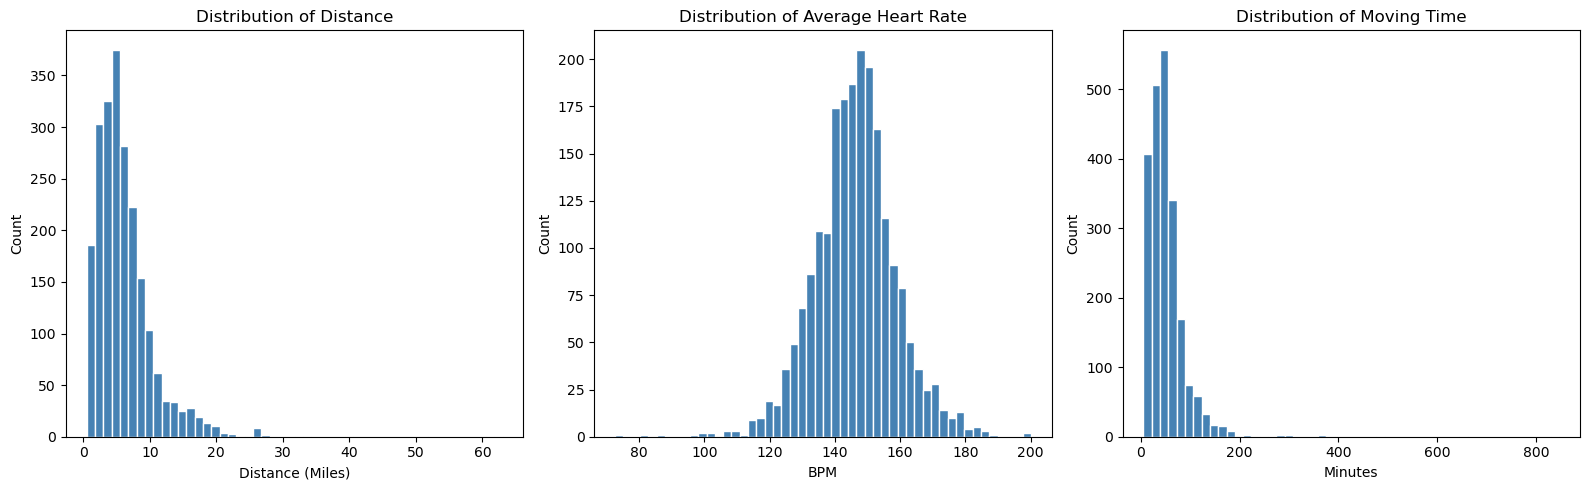

In [35]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].hist(running_df['DISTANCE_MILES'].dropna(), bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Distribution of Distance')
axes[0].set_xlabel('Distance (Miles)')
axes[0].set_ylabel('Count')

axes[1].hist(running_df['AVERAGE_HEARTRATE'].dropna(), bins=50, color='steelblue', edgecolor='white')
axes[1].set_title('Distribution of Average Heart Rate')
axes[1].set_xlabel('BPM')
axes[1].set_ylabel('Count')

axes[2].hist(running_df['MOVING_TIME_MINUTES'].dropna(), bins=50, color='steelblue', edgecolor='white')
axes[2].set_title('Distribution of Moving Time')
axes[2].set_xlabel('Minutes')
axes[2].set_ylabel('Count')

plt.tight_layout()
plt.savefig('distributions_before_outlier_removal.png', dpi=150, bbox_inches='tight')
plt.show()

In [36]:
# Remove ultramarathons (over 27 miles)
running_df = running_df[running_df['DISTANCE_MILES'] <= 27]

running_df.shape

(2193, 65)

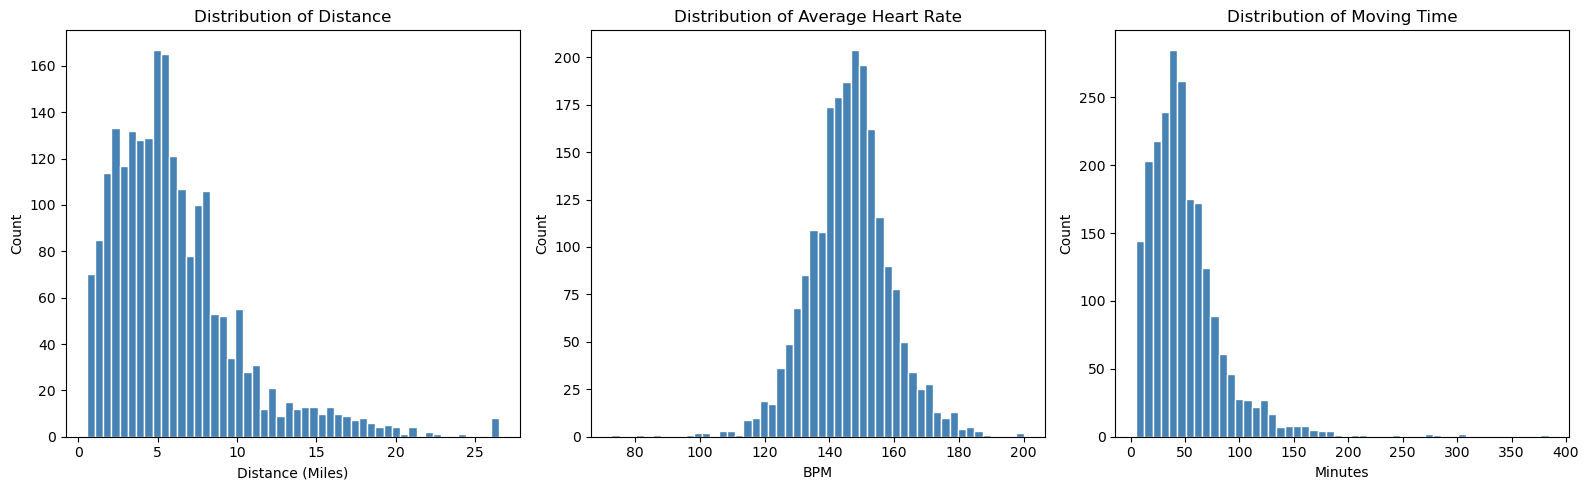

In [37]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].hist(running_df['DISTANCE_MILES'].dropna(), bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Distribution of Distance')
axes[0].set_xlabel('Distance (Miles)')
axes[0].set_ylabel('Count')

axes[1].hist(running_df['AVERAGE_HEARTRATE'].dropna(), bins=50, color='steelblue', edgecolor='white')
axes[1].set_title('Distribution of Average Heart Rate')
axes[1].set_xlabel('BPM')
axes[1].set_ylabel('Count')

axes[2].hist(running_df['MOVING_TIME_MINUTES'].dropna(), bins=50, color='steelblue', edgecolor='white')
axes[2].set_title('Distribution of Moving Time')
axes[2].set_xlabel('Minutes')
axes[2].set_ylabel('Count')

plt.tight_layout()
plt.savefig('distributions_clean.png', dpi=150, bbox_inches='tight')
plt.show()

In [38]:
running_df['WORKOUT_TYPE'].value_counts()

WORKOUT_TYPE
0.0    1352
2.0     152
3.0     138
1.0      41
Name: count, dtype: int64

In [39]:
# feature engineering ahead of EDA and modeling
workout_mapping = {
    0.0: 'Default',
    1.0: 'Race',
    2.0: 'Long Run',
    3.0: 'Workout'
}
running_df['WORKOUT_CATEGORY'] = running_df['WORKOUT_TYPE'].map(workout_mapping)

# photo included
running_df['HAS_PHOTO'] = (running_df['TOTAL_PHOTO_COUNT'] > 0).astype(int)

# custom title binary
default_titles = ['Morning Run', 'Afternoon Run', 'Evening Run', 'Night Run', 'Lunch Run', 'Morning Walk', 'Afternoon Walk']
running_df['HAS_CUSTOM_TITLE'] = (~running_df['NAME'].isin(default_titles)).astype(int)

# Activity hour
running_df['ACTIVITY_HOUR'] = running_df['START_DATE_LOCAL'].dt.hour

In [40]:
# Time of day bins reflecting runner schedule
time_bins = [0, 5.5, 10.5, 14.5, 17, 21, 24]
time_labels = ['Night', 'Morning', 'Midday', 'Afternoon', 'Evening', 'Late Night']
running_df['TIME_OF_DAY'] = pd.cut(running_df['ACTIVITY_HOUR'], 
                                    bins=time_bins, 
                                    labels=time_labels, 
                                    right=False)

# OHE for day of week, workout category, and time of day
dow_dummies = pd.get_dummies(running_df['ACTIVITY_DAY_OF_WEEK'], prefix='DOW')
workout_dummies = pd.get_dummies(running_df['WORKOUT_CATEGORY'], prefix='WORKOUT')
time_dummies = pd.get_dummies(running_df['TIME_OF_DAY'], prefix='TOD')

running_df = pd.concat([running_df, dow_dummies, workout_dummies, time_dummies], axis=1)

In [41]:
running_df['TIME_OF_DAY'].value_counts()

TIME_OF_DAY
Morning       1584
Evening        275
Midday         136
Afternoon      109
Night           82
Late Night       7
Name: count, dtype: int64

## Exploratory Data Analysis

This section explores 7 years of personal running data across three themes that form the foundation of our product pitch to the Strava Product Team:

1. **Training Volume & Injury Prevention** — How has training load changed over time, and what behavioral patterns emerge that could predict injury risk? This analysis sets up the Acute:Chronic Workload Ratio (ACWR) model.

2. **Engagement Intelligence** — What drives kudos and social interaction on Strava? Understanding the features most correlated with engagement informs a predictive model that could help Strava surface the right prompts to athletes at the right moment.

3. **Conditions Impact** — How do weather conditions relate to running performance and heart rate? This analysis explores whether environmental data can add meaningful signal to performance intelligence features.

All EDA is conducted on `running_df` — a cleaned dataset of 2,192 runs spanning 2018–2026. Where weather data is required, analysis is conducted on the subset of 2,083 runs with matched hourly weather conditions.

A key theme throughout this analysis is that single-athlete data reveals compelling patterns and proof-of-concept insights, but the real power of these features would emerge at platform scale across millions of Strava athletes.

### Training Volume and Injury Prevention

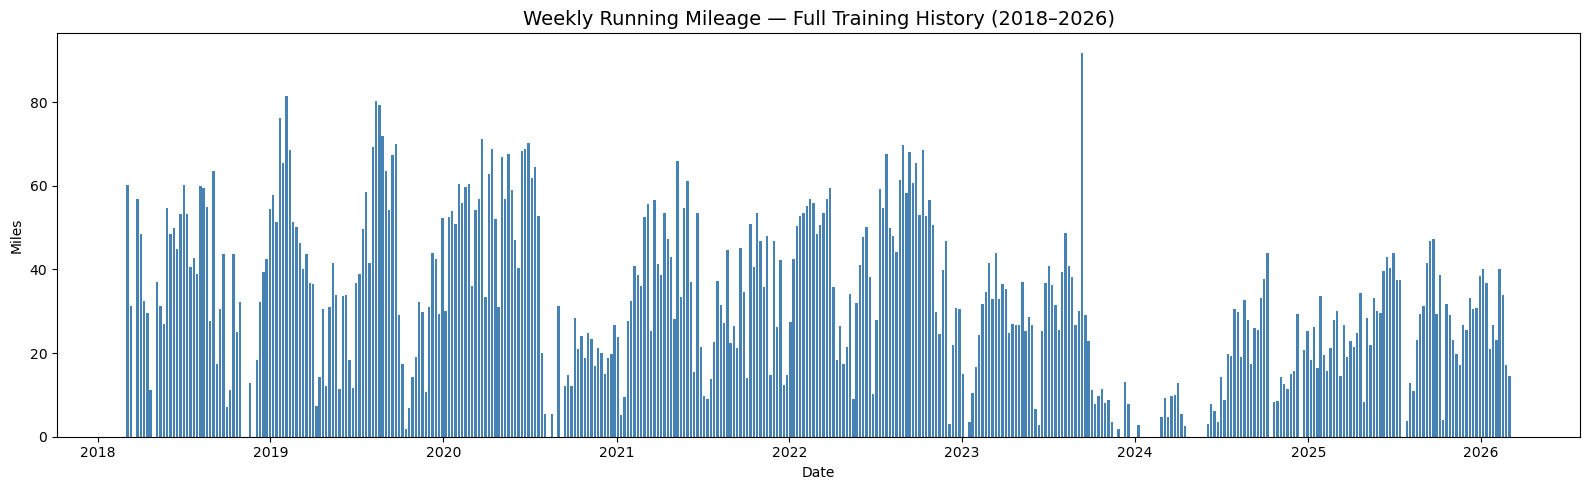

In [42]:
weekly_mileage = running_df.groupby(['ISO_YEAR', 'ISO_WEEK'])['DISTANCE_MILES'].sum().reset_index()
weekly_mileage['WEEK_START'] = pd.to_datetime(
    weekly_mileage['ISO_YEAR'].astype(str) + 
    weekly_mileage['ISO_WEEK'].astype(str) + '1', 
    format='%G%V%u'
)
weekly_mileage = weekly_mileage.sort_values('WEEK_START')

fig, ax = plt.subplots(figsize=(16, 5))
ax.bar(weekly_mileage['WEEK_START'], weekly_mileage['DISTANCE_MILES'], 
       width=5, color='steelblue', edgecolor='none')
ax.set_title('Weekly Running Mileage — Full Training History (2018–2026)', fontsize=14)
ax.set_xlabel('Date')
ax.set_ylabel('Miles')
plt.tight_layout()
plt.savefig('weekly_mileage_full_history.png', dpi=150, bbox_inches='tight')
plt.show()

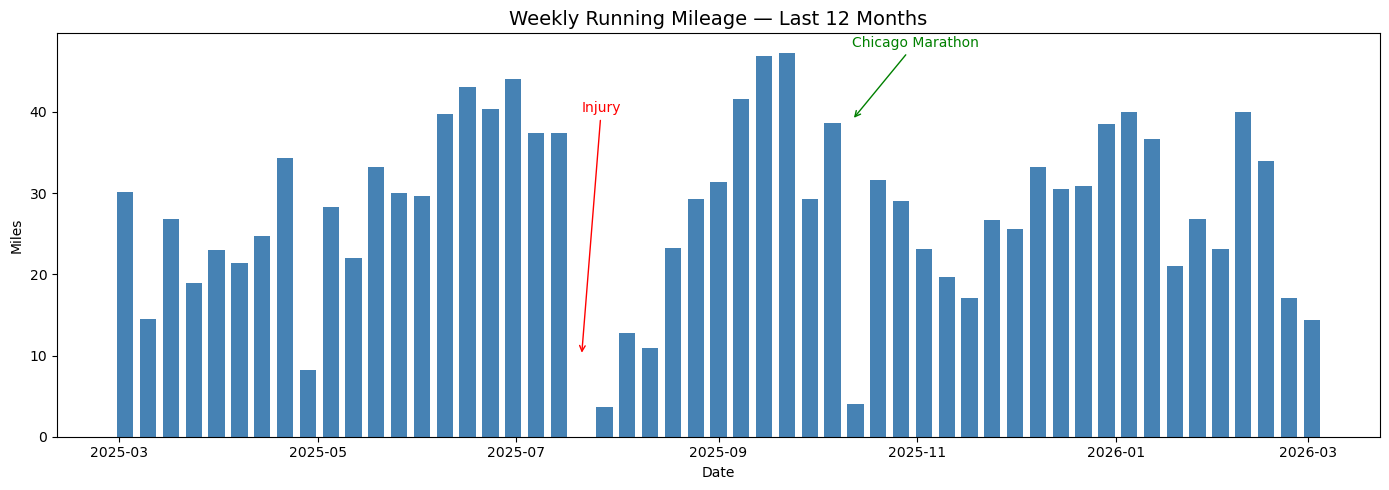

In [43]:
cutoff_date = weekly_mileage['WEEK_START'].max() - pd.DateOffset(months=12)
weekly_mileage_12m = weekly_mileage[weekly_mileage['WEEK_START'] >= cutoff_date]

fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(weekly_mileage_12m['WEEK_START'], weekly_mileage_12m['DISTANCE_MILES'],
       width=5, color='steelblue', edgecolor='none')

# Annotate injury
ax.annotate('Injury', 
            xy=(pd.Timestamp('2025-07-21'), 10), 
            xytext=(pd.Timestamp('2025-07-21'), 40),
            arrowprops=dict(arrowstyle='->', color='red'),
            color='red', fontsize=10)

# Annotate marathon
ax.annotate('Chicago Marathon', 
            xy=(pd.Timestamp('2025-10-12'), 39), 
            xytext=(pd.Timestamp('2025-10-12'), 48),
            arrowprops=dict(arrowstyle='->', color='green'),
            color='green', fontsize=10)

ax.set_title('Weekly Running Mileage — Last 12 Months', fontsize=14)
ax.set_xlabel('Date')
ax.set_ylabel('Miles')
plt.tight_layout()
plt.savefig('weekly_mileage_12_months.png', dpi=150, bbox_inches='tight')
plt.show()

Training Volume — Weekly Mileage

The charts above show weekly running mileage across my full 7-year training history (2018–2026) and zoomed into the last 12 months.

The full history reveals a consistent pattern of peaks and valleys with periods of high training load followed by sharp drops that correspond to injuries, recovery periods, and life interruptions. This variability is not unique to this athlete; it is the norm across endurance training.

The last 12 months tells a particularly clear story. Training volume built steadily through spring and summer 2025, peaking in late July before a sudden drop corresponding to an injury sustained at peak load. The athlete recovered, rebuilt mileage through September, and peaked again for the Chicago Marathon in October 2025.

This is precisely the pattern the Acute:Chronic Workload Ratio (ACWR) model is designed to detect. Had a tool flagged the rapid mileage increase in the weeks before the July injury, training load could have been moderated and the injury potentially avoided. This is the core product opportunity we are building toward.

In [44]:
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

# Full date range for denominator calculation
date_range = pd.date_range(start=running_df['START_DATE_LOCAL'].min(),
                           end=running_df['START_DATE_LOCAL'].max(), freq='D')
date_range_df = pd.DataFrame({'date': date_range})
date_range_df['day_of_week'] = date_range_df['date'].dt.day_name()
total_days_by_dow = date_range_df['day_of_week'].value_counts().reindex(day_order)

# Days with at least one run
run_days = running_df.copy()
run_days['DATE_ONLY'] = run_days['START_DATE_LOCAL'].dt.date
active_days_by_dow = run_days.drop_duplicates(subset='DATE_ONLY')['ACTIVITY_DAY_OF_WEEK'].value_counts().reindex(day_order)

# Combined summary table
dow_summary = running_df.groupby('ACTIVITY_DAY_OF_WEEK').agg(
    run_count=('ID', 'count'),
    total_time=('MOVING_TIME_MINUTES', 'sum')
).reindex(day_order).reset_index()
dow_summary['pct_active'] = (active_days_by_dow.values / total_days_by_dow.values * 100)

dow_summary

,ACTIVITY_DAY_OF_WEEK,run_count,total_time,pct_active
0,Monday,263,11143.050000,44.497608
1,Tuesday,388,16588.816667,66.985646
2,Wednesday,305,14638.816667,60.047847
3,Thursday,348,15361.750000,61.870504
4,Friday,245,10961.683333,49.880096
5,Saturday,353,24851.683333,69.784173
6,Sunday,291,15477.750000,56.594724


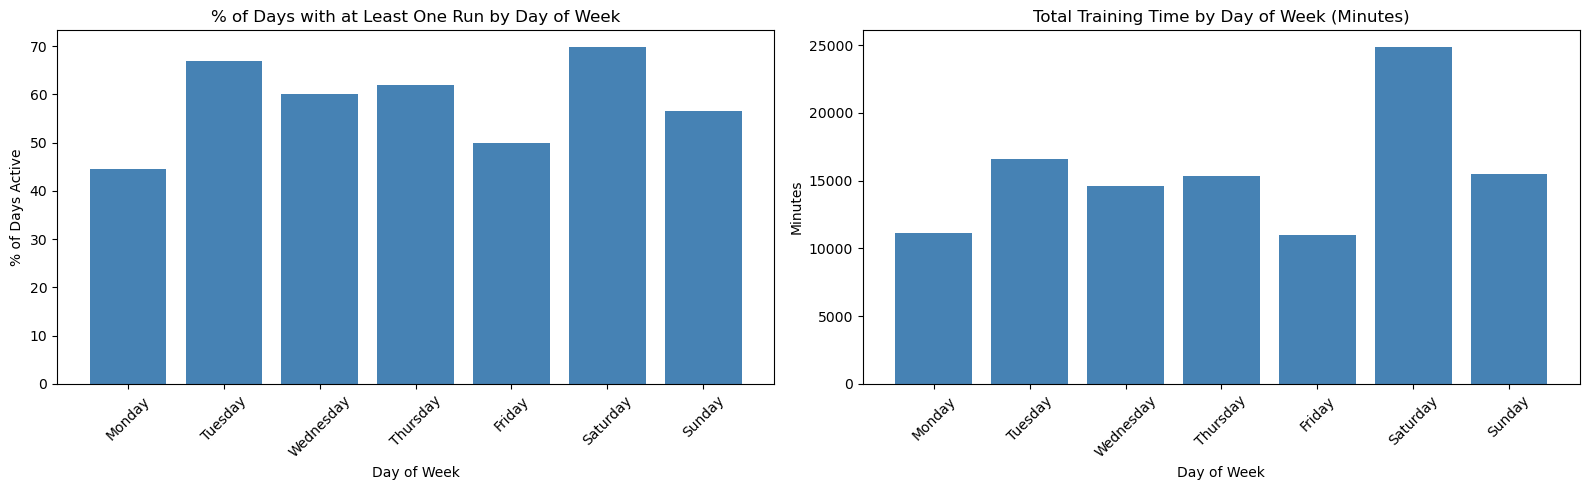

In [45]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Chart 1 - % of days active
axes[0].bar(dow_summary['ACTIVITY_DAY_OF_WEEK'], dow_summary['pct_active'],
            color='steelblue', edgecolor='none')
axes[0].set_title('% of Days with at Least One Run by Day of Week')
axes[0].set_xlabel('Day of Week')
axes[0].set_ylabel('% of Days Active')
axes[0].tick_params(axis='x', rotation=45)

# Chart 2 - total training time
axes[1].bar(dow_summary['ACTIVITY_DAY_OF_WEEK'], dow_summary['total_time'],
            color='steelblue', edgecolor='none')
axes[1].set_title('Total Training Time by Day of Week (Minutes)')
axes[1].set_xlabel('Day of Week')
axes[1].set_ylabel('Minutes')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('training_patterns_day_of_week.png', dpi=150, bbox_inches='tight')
plt.show()

Training Patterns by Day of Week

The charts above show two complementary views of training behavior by day of week: how frequently I run on each day (as a percentage of all available days) and how much total time I invest in training on each day.

Saturday stands out as the highest volume day on both metrics, consistent with the endurance athlete pattern of reserving the long run for the weekend. Tuesday and Thursday show high frequency, reflecting typical midweek workout days. Monday and Friday are the lowest activity days across both metrics.

For the Product Team, this pattern has direct product implications. Monday and Friday represent the lowest engagement days in the training week which creates an opportunity to drive activity through targeted nudges, challenges, or social features on those days. Conversely, Saturday's dominance suggests that weekend long run content, group challenges, and social features would resonate most strongly with this athlete segment.

### Engagement & Kudos Intelligence

In [46]:
running_df['KUDOS_COUNT'].describe()

count    2193.000000
mean        8.183767
std         8.838240
min         0.000000
25%         1.000000
50%         6.000000
75%        13.000000
max        95.000000
Name: KUDOS_COUNT, dtype: float64

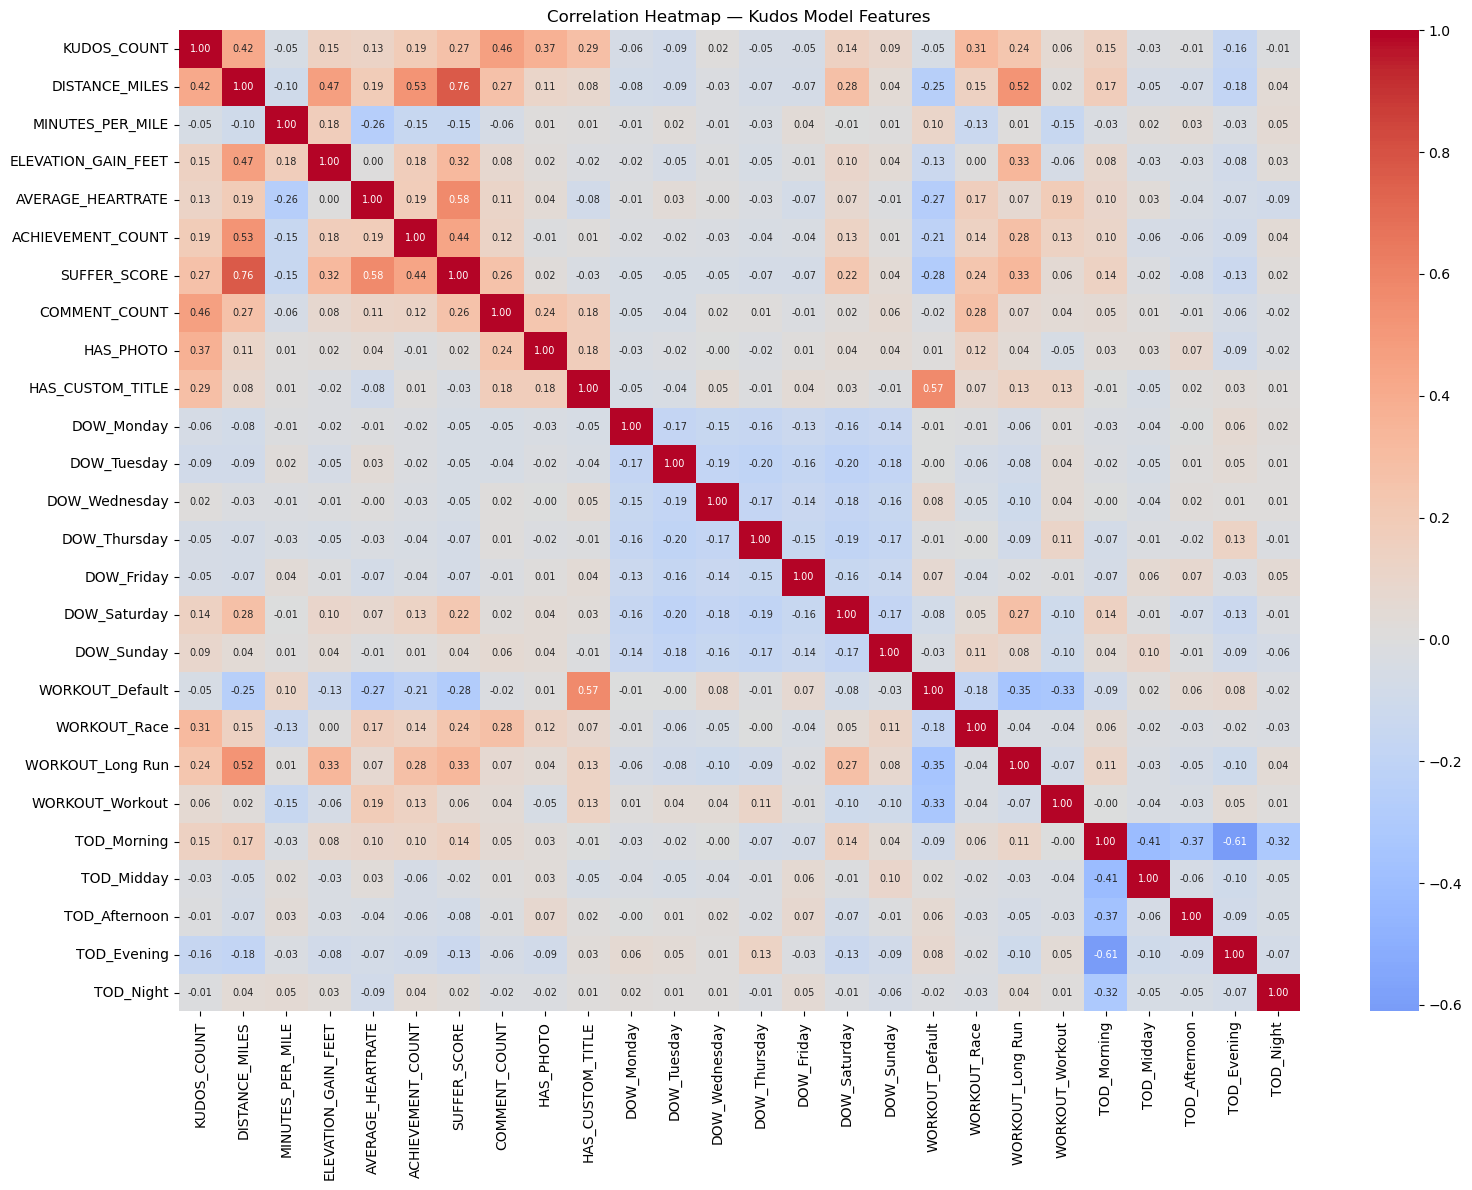

In [47]:
kudos_features = [
    'KUDOS_COUNT', 'DISTANCE_MILES', 'MINUTES_PER_MILE', 'ELEVATION_GAIN_FEET',
    'AVERAGE_HEARTRATE', 'ACHIEVEMENT_COUNT', 'SUFFER_SCORE', 'COMMENT_COUNT',
    'HAS_PHOTO', 'HAS_CUSTOM_TITLE',
    'DOW_Monday', 'DOW_Tuesday', 'DOW_Wednesday', 'DOW_Thursday', 
    'DOW_Friday', 'DOW_Saturday', 'DOW_Sunday',
    'WORKOUT_Default', 'WORKOUT_Race', 'WORKOUT_Long Run', 'WORKOUT_Workout',
    'TOD_Morning', 'TOD_Midday', 'TOD_Afternoon', 'TOD_Evening', 'TOD_Night'
]

corr_matrix = running_df[kudos_features].corr()

fig, ax = plt.subplots(figsize=(16, 12))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, ax=ax, annot_kws={'size': 7})
ax.set_title('Correlation Heatmap — Kudos Model Features')
plt.tight_layout()
plt.savefig('kudos_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

Engagement Intelligence — Kudos Correlations

The heatmap above explores correlations between kudos count and a range of potential predictive features across 2,192 runs.

**Key findings:**

The strongest predictors of kudos are `COMMENT_COUNT` (0.46), `DISTANCE_MILES` (0.42), `HAS_PHOTO` (0.37), and `HAS_CUSTOM_TITLE` (0.29). Workout type also plays a role with races and long runs both showing positive correlations with kudos, reflecting that the Strava community tends to reward harder, more meaningful efforts.

Notably, `COMMENT_COUNT` warrants careful interpretation. While it is the strongest correlated feature, comments and kudos likely reflect the same underlying engagement signal rather than one causing the other. A post that resonates with the community tends to attract both. This is a correlation vs. causation distinction worth keeping in mind when interpreting model results.

`MINUTES_PER_MILE` shows a near-zero correlation with kudos so it seems pace alone does not drive engagement. This makes intuitive sense: a fast 3-mile tempo run may generate fewer kudos than a slow 20-mile long run. 

Interestingly, day of week and time of day show almost no correlation with kudos, suggesting that *when* you run matters far less than *what* you ran.

**Product implication:** Strava should continue to use these signals to prompt athletes to add photos or customize their activity titles at the point of upload as these two features are directly correlated with higher engagement that require minimal athlete effort to implement.

### Conditions Impact

In [48]:
# Join running data with weather data on activity ID
running_weather_df = running_df.merge(weather_df, on='ID', how='left')

print(f"Running df: {len(running_df)} rows")
print(f"Running + weather df: {len(running_weather_df)} rows")
running_weather_df[['TEMPERATURE', 'FEELS_LIKE', 'HUMIDITY', 'WIND_SPEED', 'PRECIPITATION']].isnull().sum()

Running df: 2193 rows
Running + weather df: 2193 rows


TEMPERATURE      110
FEELS_LIKE       110
HUMIDITY         110
WIND_SPEED       110
PRECIPITATION    110
dtype: int64

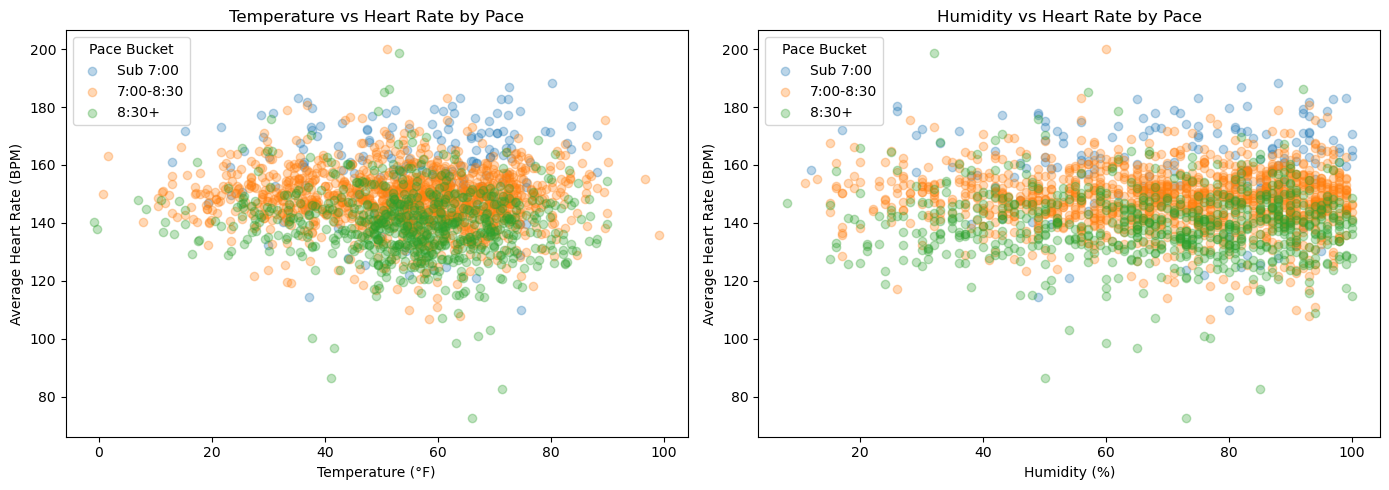

In [49]:
pace_bins = [0, 7, 8.5, float('inf')]
pace_labels = ['Sub 7:00', '7:00-8:30', '8:30+']
weather_hr_df = running_weather_df.dropna(subset=['AVERAGE_HEARTRATE', 'TEMPERATURE', 'HUMIDITY'])
weather_hr_df['PACE_BUCKET'] = pd.cut(weather_hr_df['MINUTES_PER_MILE'], 
                                       bins=pace_bins, 
                                       labels=pace_labels)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for label in pace_labels:
    subset = weather_hr_df[weather_hr_df['PACE_BUCKET'] == label]
    axes[0].scatter(subset['TEMPERATURE'], subset['AVERAGE_HEARTRATE'], 
                    alpha=0.3, label=label)
    axes[1].scatter(subset['HUMIDITY'], subset['AVERAGE_HEARTRATE'], 
                    alpha=0.3, label=label)

axes[0].set_title('Temperature vs Heart Rate by Pace')
axes[0].set_xlabel('Temperature (°F)')
axes[0].set_ylabel('Average Heart Rate (BPM)')
axes[0].legend(title='Pace Bucket')

axes[1].set_title('Humidity vs Heart Rate by Pace')
axes[1].set_xlabel('Humidity (%)')
axes[1].set_ylabel('Average Heart Rate (BPM)')
axes[1].legend(title='Pace Bucket')

plt.tight_layout()
plt.savefig('weather_vs_heartrate.png', dpi=150, bbox_inches='tight')
plt.show()

Conditions Impact — Weather vs Heart Rate

The scatter plots above explore whether temperature and humidity explain variation in average heart rate across runs.

**Finding:** No clear relationship between temperature or humidity and heart rate was observed, even when controlling for pace and isolating a single training year.

This is likely explained by the complexity of heart rate as a metric. Heart rate on any given run is influenced by a combination of factors like cumulative fatigue, sleep quality, hydration, distance within the run, and day-to-day physiological variation that weather conditions alone cannot explain. A single weather reading at the start of a run does not capture the full environmental context of the effort.

**What this tells us as a product opportunity:** Rather than a simple weather-to-heart-rate relationship, a more powerful feature would combine multiple signals such as  weather, sleep, training load, and recovery status to predict expected heart rate and flag when an athlete is working harder than conditions warrant. This is the kind of intelligence layer that Strava is uniquely positioned to build at platform scale, and that this analysis points toward as a future state recommendation.

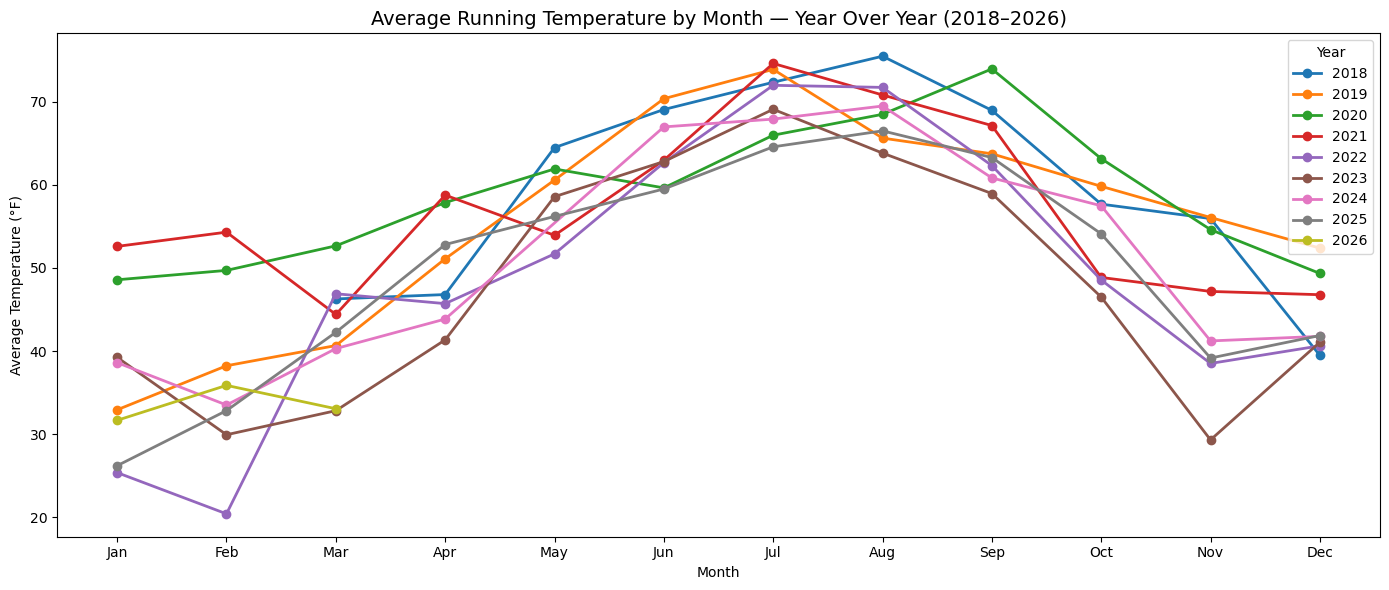

In [50]:
monthly_weather = running_weather_df.dropna(subset=['TEMPERATURE']).copy()
monthly_weather['MONTH'] = monthly_weather['START_DATE_LOCAL'].dt.month
monthly_weather['YEAR'] = monthly_weather['START_DATE_LOCAL'].dt.year

monthly_by_year = monthly_weather.groupby(['YEAR', 'MONTH']).agg(
    avg_temp=('TEMPERATURE', 'mean')
).reset_index()

month_labels = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
                'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

# Color palette — one color per year
colors = plt.cm.tab10.colors

fig, ax = plt.subplots(figsize=(14, 6))

for idx, year in enumerate(sorted(monthly_by_year['YEAR'].unique())):
    year_data = monthly_by_year[monthly_by_year['YEAR'] == year]
    ax.plot(year_data['MONTH'], year_data['avg_temp'],
            color=colors[idx], linewidth=2, marker='o', label=str(year))

ax.set_title('Average Running Temperature by Month — Year Over Year (2018–2026)', fontsize=14)
ax.set_xlabel('Month')
ax.set_ylabel('Average Temperature (°F)')
ax.set_xticks(range(1, 13))
ax.set_xticklabels(month_labels)
ax.legend(title='Year', loc='upper right')
plt.tight_layout()
plt.savefig('seasonal_temperature_by_year.png', dpi=150, bbox_inches='tight')
plt.show()

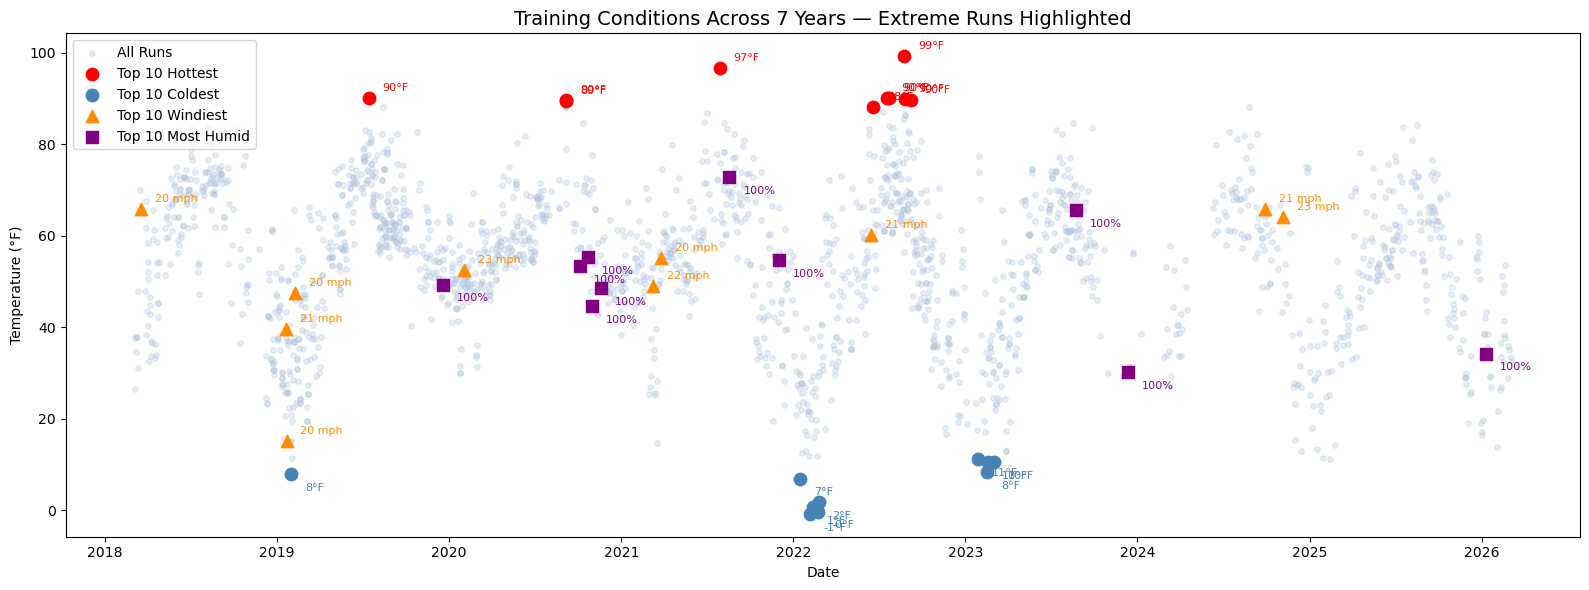

In [51]:
extreme_df = running_weather_df.dropna(subset=['TEMPERATURE', 'WIND_SPEED', 'HUMIDITY']).copy()

top_hot  = extreme_df.nlargest(10, 'TEMPERATURE')
top_cold = extreme_df.nsmallest(10, 'TEMPERATURE')
top_wind = extreme_df.nlargest(10, 'WIND_SPEED')
top_humid = extreme_df.nlargest(10, 'HUMIDITY')

fig, ax = plt.subplots(figsize=(16, 6))

ax.scatter(extreme_df['START_DATE_LOCAL'], extreme_df['TEMPERATURE'],
           color='lightsteelblue', alpha=0.3, s=15, label='All Runs')

ax.scatter(top_hot['START_DATE_LOCAL'], top_hot['TEMPERATURE'],
           color='red', s=80, zorder=5, label='Top 10 Hottest')

ax.scatter(top_cold['START_DATE_LOCAL'], top_cold['TEMPERATURE'],
           color='steelblue', s=80, zorder=5, label='Top 10 Coldest')

ax.scatter(top_wind['START_DATE_LOCAL'], top_wind['TEMPERATURE'],
           color='darkorange', s=80, marker='^', zorder=5, label='Top 10 Windiest')

ax.scatter(top_humid['START_DATE_LOCAL'], top_humid['TEMPERATURE'],
           color='purple', s=80, marker='s', zorder=5, label='Top 10 Most Humid')

for _, row in top_hot.iterrows():
    ax.annotate(f"{row['TEMPERATURE']:.0f}°F",
                xy=(row['START_DATE_LOCAL'], row['TEMPERATURE']),
                xytext=(10, 5), textcoords='offset points',
                fontsize=8, color='red')

for _, row in top_cold.iterrows():
    ax.annotate(f"{row['TEMPERATURE']:.0f}°F",
                xy=(row['START_DATE_LOCAL'], row['TEMPERATURE']),
                xytext=(10, -12), textcoords='offset points',
                fontsize=8, color='steelblue')

for _, row in top_wind.iterrows():
    ax.annotate(f"{row['WIND_SPEED']:.0f} mph",
                xy=(row['START_DATE_LOCAL'], row['TEMPERATURE']),
                xytext=(10, 5), textcoords='offset points',
                fontsize=8, color='darkorange')

for _, row in top_humid.iterrows():
    ax.annotate(f"{row['HUMIDITY']:.0f}%",
                xy=(row['START_DATE_LOCAL'], row['TEMPERATURE']),
                xytext=(10, -12), textcoords='offset points',
                fontsize=8, color='purple')

ax.set_title('Training Conditions Across 7 Years — Extreme Runs Highlighted', fontsize=14)
ax.set_xlabel('Date')
ax.set_ylabel('Temperature (°F)')
ax.legend(loc='upper left')
plt.tight_layout()
plt.savefig('extreme_runs_highlighted.png', dpi=150, bbox_inches='tight')
plt.show()

Conditions Impact — Seasonal Patterns & Extreme Runs

The two charts above explore 7 years of training conditions from complementary angles.

**Seasonal Temperature Patterns**
Average running temperature follows a consistent seasonal arc across all seven years, peaking between 65–75°F in July and August and bottoming out between 20–40°F in January and February.

**Extreme Runs Highlighted**
The second chart plots every run by date and temperature, with the top 10 hottest (red), coldest (blue), windiest (orange), and most humid (purple) runs called out. The hottest run on record was 99°F in summer 2022. The coldest cluster occurred in early 2022, bottoming out at -1°F. Windiest runs range from 21–23 mph.

**Product Implication — Year in Sport**
Strava already captures all of this data. A Year in Sport feature that surfaced personalized extreme condition badges like "You ran in -1°F this year" or "Your hottest run was 99°F"  would require zero additional data collection and would drive the kind of shareable, emotionally resonant moments that define high-engagement social features. 

## Feature Engineering

Several new features were engineered earlier from the raw Strava data to support both the EDA and the two models built in this analysis.

**Activity-level features** — `HAS_PHOTO` and `HAS_CUSTOM_TITLE` were created as binary flags to capture social engagement intent at the point of upload. `WORKOUT_CATEGORY` translated Strava's numeric workout type field into labeled categories. `ACTIVITY_HOUR` and `TIME_OF_DAY` bins were derived from activity start time to capture training schedule patterns.

**Unit conversions** — Raw Strava API fields were converted from metric to imperial units throughout: meters to miles, meters per second to minutes per mile, and meters to feet for elevation. Cadence was doubled from half-cadence to full steps per minute.

**Acute:Chronic Workload Ratio (ACWR)** — The most significant feature engineering in this analysis. A rolling 4-week baseline was calculated from weekly long run data, with a safe ceiling defined as 110% of that baseline per Frandsen et al. (2025). Weeks were flagged as OK, Exceeded, Calibrating, or No Recommendation based on training history. A simulated safe progression was then modeled to show what a disciplined training trajectory would have looked like — feeding capped values back into subsequent weeks' baseline calculations dynamically.

In [52]:
# Build ACWR (Acute:Chronic Workload Ratio) by calculating each week's longest run, comparing it to a 4-week rolling average baseline, and flagging weeks where the longest run exceeded the safe 10% increase ceiling per Frandsen et al. (2025).
# Weeks with 2+ zero-run weeks in the prior 4 weeks are flagged as Calibrating to account for returns from injury or extended breaks.

running_df['RUN_DATE'] = running_df['START_DATE_LOCAL'].dt.date

daily_runs = running_df.groupby(['ISO_YEAR', 'ISO_WEEK', 'RUN_DATE'])['DISTANCE_MILES'].sum().reset_index()
daily_runs.columns = ['ISO_YEAR', 'ISO_WEEK', 'RUN_DATE', 'DAILY_MILES']

weekly_long_run = daily_runs.groupby(['ISO_YEAR', 'ISO_WEEK']).agg(
    longest_run=('DAILY_MILES', 'max'),
    run_days=('DAILY_MILES', 'count')
).reset_index()

all_weeks_iso = pd.DataFrame({'WEEK_START': pd.date_range(
    start=running_df['START_DATE_LOCAL'].min(), 
    end=running_df['START_DATE_LOCAL'].max(), 
    freq='W-MON'
)})
all_weeks_iso['ISO_YEAR'] = all_weeks_iso['WEEK_START'].dt.isocalendar()['year']
all_weeks_iso['ISO_WEEK'] = all_weeks_iso['WEEK_START'].dt.isocalendar()['week']

acwr_df = all_weeks_iso.merge(weekly_long_run, on=['ISO_YEAR', 'ISO_WEEK'], how='left')
acwr_df['longest_run'] = acwr_df['longest_run'].fillna(0)
acwr_df['run_days'] = acwr_df['run_days'].fillna(0)

acwr_df['rolling_4wk_avg'] = acwr_df['longest_run'].shift(1).rolling(window=4, min_periods=4).mean()
acwr_df['safe_ceiling'] = acwr_df['rolling_4wk_avg'] * 1.10
acwr_df['runs_last_4wks'] = acwr_df['run_days'].rolling(window=4, min_periods=4).sum()
acwr_df['zero_weeks_last_4'] = (acwr_df['longest_run'] == 0).shift(1).rolling(window=4, min_periods=4).sum()

acwr_df['flag'] = 'OK'
acwr_df.loc[acwr_df['rolling_4wk_avg'].isna(), 'flag'] = 'Calibrating'
acwr_df.loc[acwr_df['zero_weeks_last_4'] >= 2, 'flag'] = 'Calibrating'
acwr_df.loc[acwr_df['runs_last_4wks'] < 2, 'flag'] = 'No Recommendation'
acwr_df.loc[(acwr_df['flag'] == 'OK') & (acwr_df['longest_run'] > acwr_df['safe_ceiling']), 'flag'] = 'Exceeded'

acwr_df['flag'].value_counts()

flag
OK                   235
Exceeded             151
Calibrating           20
No Recommendation     12
Name: count, dtype: int64

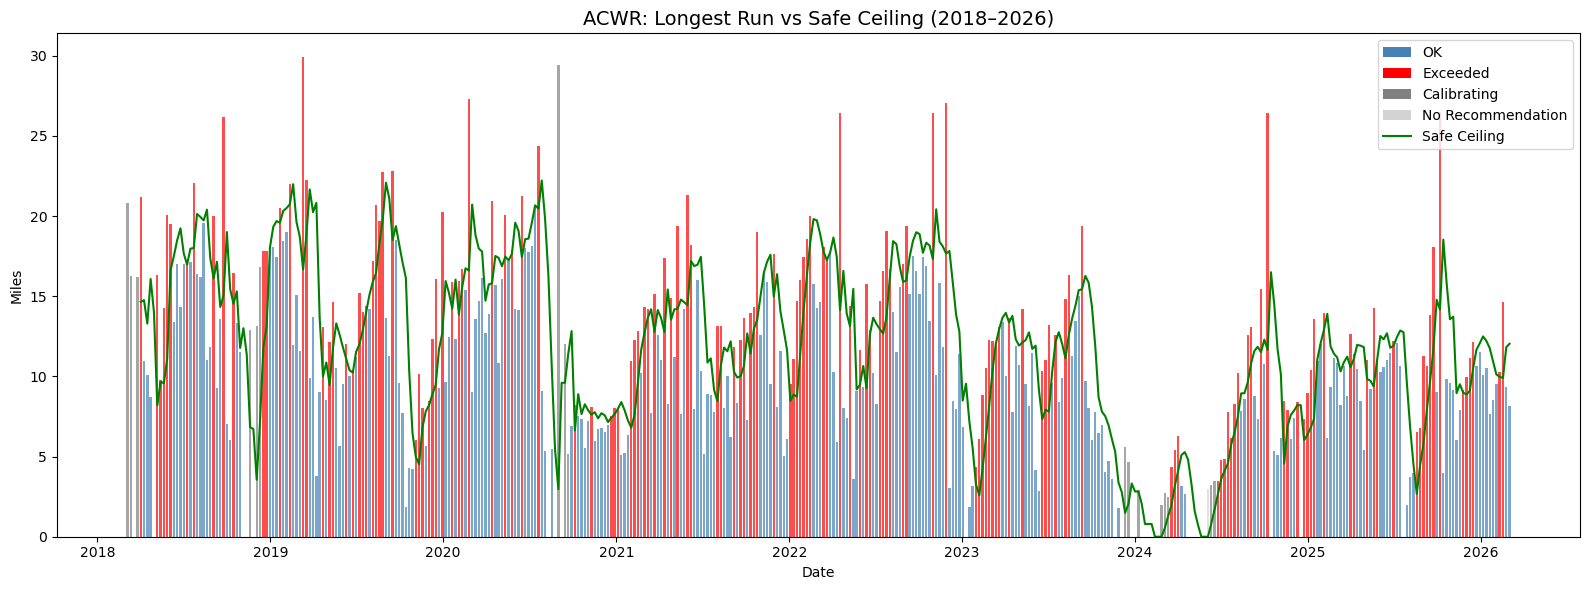

In [53]:
fig, ax = plt.subplots(figsize=(16, 6))

colors = acwr_df['flag'].map({
    'OK': 'steelblue',
    'Exceeded': 'red',
    'Calibrating': 'gray',
    'No Recommendation': 'lightgray'
})

ax.bar(acwr_df['WEEK_START'], acwr_df['longest_run'], 
       width=5, color=colors, edgecolor='none', alpha=0.7)
ax.plot(acwr_df['WEEK_START'], acwr_df['safe_ceiling'], 
        color='green', linewidth=1.5, label='Safe Ceiling (10%)')

ax.set_title('ACWR: Longest Run vs Safe Ceiling (2018–2026)', fontsize=14)
ax.set_xlabel('Date')
ax.set_ylabel('Miles')

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='steelblue', label='OK'),
    Patch(facecolor='red', label='Exceeded'),
    Patch(facecolor='gray', label='Calibrating'),
    Patch(facecolor='lightgray', label='No Recommendation'),
    plt.Line2D([0], [0], color='green', linewidth=1.5, label='Safe Ceiling')
]
ax.legend(handles=legend_elements)
plt.tight_layout()
plt.savefig('acwr_full_history.png', dpi=150, bbox_inches='tight')
plt.show()

### ACWR Injury Risk Dashboard

The chart below visualizes the Acute:Chronic Workload Ratio (ACWR) framework applied to 2025 training data. Each bar represents the longest run of that week, colored by risk status. The green line shows the actual safe ceiling — 110% of the prior 4-week rolling average — updated each week based on real training load. The orange dashed line shows the simulated safe ceiling: what the progression could have looked like if training load had been capped at the safe ceiling every week it was exceeded.

**What the data shows:** Training load through June and July 2025 was largely well-managed, with most weeks falling within the safe ceiling. The mid-year injury appears to have been an isolated event rather than the result of chronic overtraining.

**Where the dashboard would have added real value:** The September and October rebuild tells a different story. Coming back from injury, weekly long runs frequently exceeded the safe ceiling as fitness was rebuilt aggressively in preparation for the Chicago Marathon. This is precisely the high-risk return-to-training window where an ACWR warning would have urged caution.

The simulated ceiling (orange) illustrates how a more controlled rebuild could have maintained a stable, gradually increasing baseline rather than the volatile spikes seen in the actual data.

**Product Vision — Athlete-Facing Dashboard**

The ACWR framework is only valuable if it reaches the athlete in a simple, actionable format. Below is a proof-of-concept dashboard that translates this analysis into a weekly recommendation any athlete can act on. It surfaces three things: your 4-week rolling baseline, this week's safe long run ceiling, and your current risk status. This is the kind of proactive intelligence layer that Strava is uniquely positioned to deliver and that no current feature in the product provides.

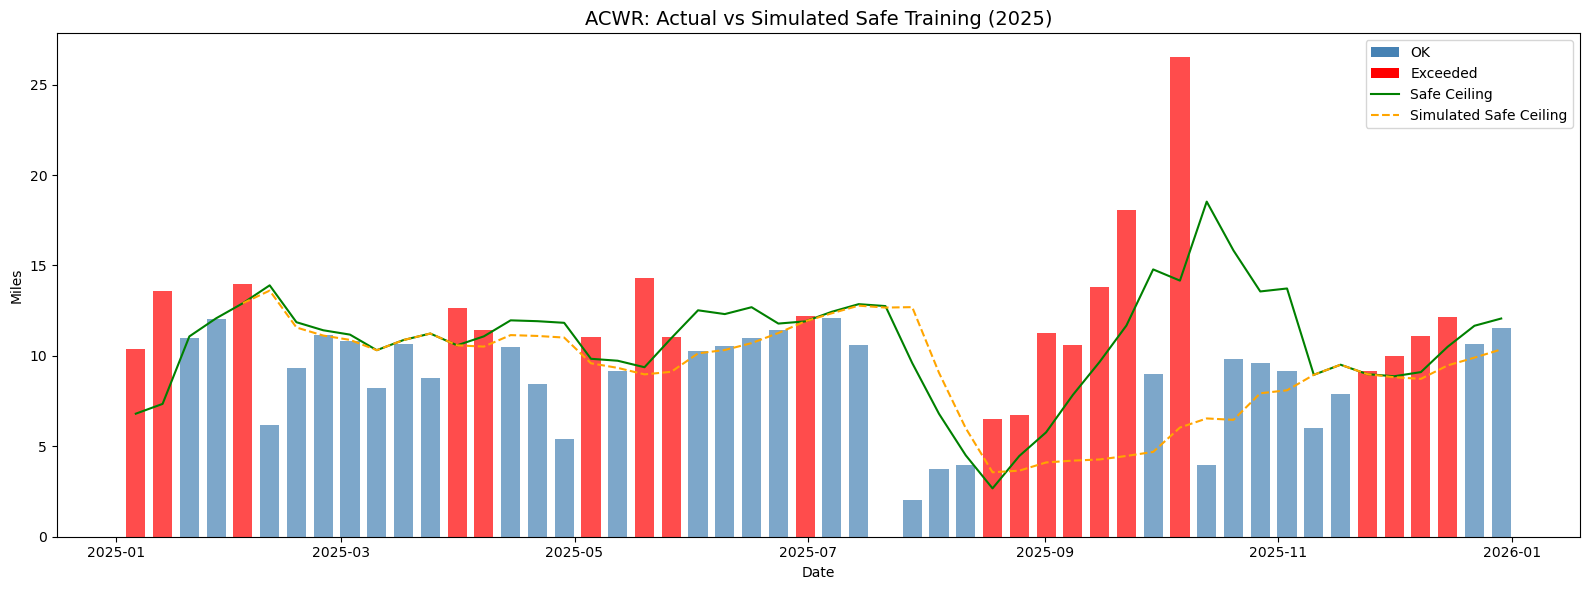

In [54]:
acwr_2025 = acwr_df[acwr_df['WEEK_START'].dt.year == 2025]
simulated_runs = []
simulated_ceiling = []

for i in range(len(acwr_2025)):
    if i < 4:
        simulated_ceiling.append(np.nan)
        simulated_runs.append(acwr_2025['longest_run'].iloc[i])
    else:
        # Calculate ceiling from prior 4 weeks of SIMULATED runs
        prior = [r for r in simulated_runs[i-4:i] if r > 0]
        if len(prior) == 0:
            ceiling = np.nan
        else:
            ceiling = np.mean(prior) * 1.10
        simulated_ceiling.append(ceiling)
        
        # Now cap this week's run against the simulated ceiling
        actual = acwr_2025['longest_run'].iloc[i]
        flag = acwr_2025['flag'].iloc[i]
        if flag == 'Exceeded' and not np.isnan(ceiling):
            simulated_runs.append(ceiling)
        else:
            simulated_runs.append(actual)

acwr_2025['simulated_ceiling'] = simulated_ceiling

fig, ax = plt.subplots(figsize=(16, 6))

colors = acwr_2025['flag'].map({
    'OK': 'steelblue',
    'Exceeded': 'red',
    'Calibrating': 'gray',
    'No Recommendation': 'lightgray'
})

ax.bar(acwr_2025['WEEK_START'], acwr_2025['longest_run'],
       width=5, color=colors, edgecolor='none', alpha=0.7)
ax.plot(acwr_2025['WEEK_START'], acwr_2025['safe_ceiling'],
        color='green', linewidth=1.5, label='Safe Ceiling')
ax.plot(acwr_2025['WEEK_START'], acwr_2025['simulated_ceiling'],
        color='orange', linewidth=1.5, linestyle='--', label='Simulated Safe Progression')

ax.set_title('ACWR: Actual vs Simulated Safe Training (2025)', fontsize=14)
ax.set_xlabel('Date')
ax.set_ylabel('Miles')

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='steelblue', label='OK'),
    Patch(facecolor='red', label='Exceeded'),
    plt.Line2D([0], [0], color='green', linewidth=1.5, label='Safe Ceiling'),
    plt.Line2D([0], [0], color='orange', linewidth=1.5, linestyle='--', label='Simulated Safe Ceiling')
]
ax.legend(handles=legend_elements)
plt.tight_layout()
plt.savefig('acwr_2025_simulated.png', dpi=150, bbox_inches='tight')
plt.show()

In [55]:
current_week = acwr_df.iloc[-1]

print("=" * 60)
print("       🏃 WEEKLY INJURY RISK DASHBOARD")
print("=" * 60)
print()
print(f"  📊 4-Week Rolling Average:     {current_week['rolling_4wk_avg']:.1f} miles")
print()
print("  " + "=" * 56)
print(f"  🎯 THIS WEEK'S SAFE CEILING:   {current_week['safe_ceiling']:.1f} MILES")
print("  " + "=" * 56)
print()
print(f"  📍 Longest Run This Week:      {current_week['longest_run']:.1f} miles")
print()
print(f"  ⚠️  Status:                     {current_week['flag']}")
print()
print("=" * 60)

if current_week['flag'] == 'Exceeded':
    excess = current_week['longest_run'] - current_week['safe_ceiling']
    print(f"  ⚠️  WARNING: You exceeded the safe ceiling by {excess:.1f} miles!")
    print(f"  💡 Consider capping long runs at {current_week['safe_ceiling']:.1f} miles next week")
elif current_week['flag'] == 'Calibrating':
    print(f"  🔄 Your baseline is recalibrating after a training gap.")
    print(f"  💡 Start conservatively and build back gradually.")
elif current_week['flag'] == 'No Recommendation':
    print(f"  ℹ️  Not enough recent data to make a recommendation.")
else:
    remaining = current_week['safe_ceiling'] - current_week['longest_run']
    print(f"  ✅ GOOD: You have {remaining:.1f} miles of headroom this week")
print("=" * 60)

       🏃 WEEKLY INJURY RISK DASHBOARD

  📊 4-Week Rolling Average:     10.9 miles

  🎯 THIS WEEK'S SAFE CEILING:   12.0 MILES

  📍 Longest Run This Week:      8.2 miles

  ⚠️  Status:                     OK

  ✅ GOOD: You have 3.9 miles of headroom this week


## Modeling


#### Model 1: Kudos Predictor (Linear Regression)

This model predicts kudos count for a given run using activity and social features available at the time of upload.

**Model Performance**
- R²: 0.512 — the model explains approximately 51% of the variation in kudos across 2,192 runs
- RMSE: 6.5 — on average, predictions are within ~6-7 kudos of the actual count

**Feature Selection**
Day-of-week features were excluded after correlation analysis showed near-zero relationship with kudos.

**Key Findings**
- Distance, photos, and custom titles are the strongest controllable drivers of kudos
- Race and long run labels generate more engagement than default workout types, reflecting that the Strava application may be pushing these activities in feeds
- Comment count is included as a feature on the assumption that community interaction drives visibility, though directional causality between comments and kudos is difficult to establish from observational data alone
- The residual plot reveals a floor effect as kudos cannot go below zero which linear regression does not enforce. We explored a log transformation of the target variable but that had less useful results.

**Product Implication**
Two of the highest-impact levers, adding a photo and writing a custom title, require minimal effort from the athlete. Strava should prompt both behaviors at the point of upload to maximize engagement.

                            OLS Regression Results                            
Dep. Variable:            KUDOS_COUNT   R-squared:                       0.414
Model:                            OLS   Adj. R-squared:                  0.409
Method:                 Least Squares   F-statistic:                     87.71
Date:                Sun, 08 Mar 2026   Prob (F-statistic):          5.81e-190
Time:                        13:58:44   Log-Likelihood:                -5811.5
No. Observations:                1754   AIC:                         1.165e+04
Df Residuals:                    1739   BIC:                         1.174e+04
Df Model:                          14                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          8.0889      0.159     50.737      0.0

,Metric,Value
0,R²,0.512
1,Adjusted R²,0.409
2,MAE,4.949
3,RMSE,6.572


,Feature,Coefficient
0,DISTANCE_MILES,2.287126
1,TOD_Morning,2.216660
2,HAS_PHOTO,2.069056
3,COMMENT_COUNT,1.970973
4,WORKOUT_Race,1.537119
5,HAS_CUSTOM_TITLE,1.232120
6,TOD_Midday,1.102282
7,TOD_Evening,0.994064
8,TOD_Afternoon,0.904634
9,WORKOUT_Long Run,0.711352


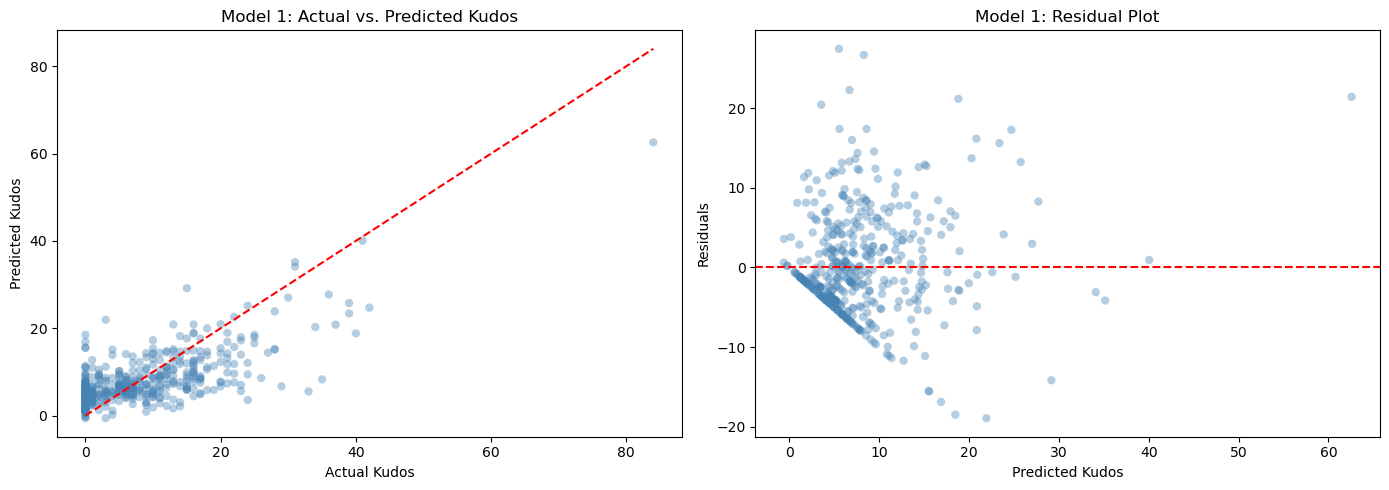

In [56]:
# Model 1: Kudos Predictor (Linear Regression)

kudos_features = [
    'DISTANCE_MILES', 'HAS_PHOTO', 'HAS_CUSTOM_TITLE', 'ACHIEVEMENT_COUNT',
    'COMMENT_COUNT',
    'WORKOUT_Default', 'WORKOUT_Race', 'WORKOUT_Long Run', 'WORKOUT_Workout',
    'TOD_Morning', 'TOD_Midday', 'TOD_Afternoon', 'TOD_Evening', 'TOD_Night'
]

X = running_df[kudos_features].dropna()
y = running_df.loc[X.index, 'KUDOS_COUNT']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

kudos_model = LinearRegression()
kudos_model.fit(X_train_scaled, y_train)
y_pred = kudos_model.predict(X_test_scaled)

X_train_sm = sm.add_constant(X_train_scaled)
kudos_ols = sm.OLS(y_train, X_train_sm).fit()
print(kudos_ols.summary())

from sklearn.metrics import mean_absolute_error

metrics_df = pd.DataFrame({
    'Metric': ['R²', 'Adjusted R²', 'MAE', 'RMSE'],
    'Value': [
        round(r2_score(y_test, y_pred), 3),
        round(kudos_ols.rsquared_adj, 3),
        round(mean_absolute_error(y_test, y_pred), 3),
        round(np.sqrt(mean_squared_error(y_test, y_pred)), 3)
    ]
})
display(metrics_df)

coef_df = pd.DataFrame({
    'Feature': kudos_features,
    'Coefficient': kudos_model.coef_
}).sort_values('Coefficient', ascending=False).reset_index(drop=True)
display(coef_df)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_test, y_pred, alpha=0.4, color='steelblue', edgecolors='none')
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth=1.5)
axes[0].set_xlabel('Actual Kudos')
axes[0].set_ylabel('Predicted Kudos')
axes[0].set_title('Model 1: Actual vs. Predicted Kudos')

residuals = y_test - y_pred
axes[1].scatter(y_pred, residuals, alpha=0.4, color='steelblue', edgecolors='none')
axes[1].axhline(0, color='red', linestyle='--', linewidth=1.5)
axes[1].set_xlabel('Predicted Kudos')
axes[1].set_ylabel('Residuals')
axes[1].set_title('Model 1: Residual Plot')

plt.tight_layout()
plt.savefig('model1_kudos_residuals.png', dpi=150, bbox_inches='tight')
plt.show()

### Model 2: Pre-Run Heart Rate Predictor (Linear Regression)

This model predicts average heart rate for a given run using effort and environmental features available before the run begins — distance, pace, elevation, and weather conditions.

**Model Performance**
- R²: 0.297 — the model explains approximately 30% of the variation in average heart rate across runs
- RMSE: 11.7 bpm — on average, predictions are within ~12 beats per minute of actual heart rate

**Feature Selection**
Pace, distance, elevation, temperature, humidity, and wind speed were selected as features that an athlete would realistically know before starting a run. 
Outliers in pace (>15 min/mile) and elevation (>2,000 feet) were removed as they represented infrequent runs that were distorting model performance.

**Key Findings**
- Elevation gain and distance are the strongest positive drivers of heart rate with harder efforts producing higher HR as expected
- Pace is the dominant feature overall as slower pace is associated with lower HR, which may also explains the apparent negative relationship between weather and HR. Athletes naturally run slower in heat and humidity, and pace absorbs that signal
- Weather conditions have limited direct explanatory power once effort level is controlled for
- Weekend days show higher raw kudos averages in isolation, but this effect disappears once distance is controlled for

**Product Implication**
This model tells us is that pace, distance, and elevation explain about 30% of HR variation, meaning 70% is driven by things this model can't see. If Strava was to integrate on top of this sleep data, HRV, recovery scores, and multi-week training load it could close the gap. The weakness of this model is the argument for why Strava needs to become a full intelligence layer.

                            OLS Regression Results                            
Dep. Variable:      AVERAGE_HEARTRATE   R-squared:                       0.262
Model:                            OLS   Adj. R-squared:                  0.260
Method:                 Least Squares   F-statistic:                     95.27
Date:                Sun, 08 Mar 2026   Prob (F-statistic):          1.48e-102
Time:                        13:58:45   Log-Likelihood:                -6067.9
No. Observations:                1613   AIC:                         1.215e+04
Df Residuals:                    1606   BIC:                         1.219e+04
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        146.2467      0.260    562.898      0.0

,Metric,Value
0,R²,0.297
1,Adjusted R²,0.260
2,MAE,8.345
3,RMSE (bpm),11.733


,Feature,Coefficient
0,ELEVATION_GAIN_FEET,1.289753
1,DISTANCE_MILES,0.613188
2,WIND_SPEED,-0.272264
3,TEMPERATURE,-0.754793
4,HUMIDITY,-1.092235
5,MINUTES_PER_MILE,-5.939964


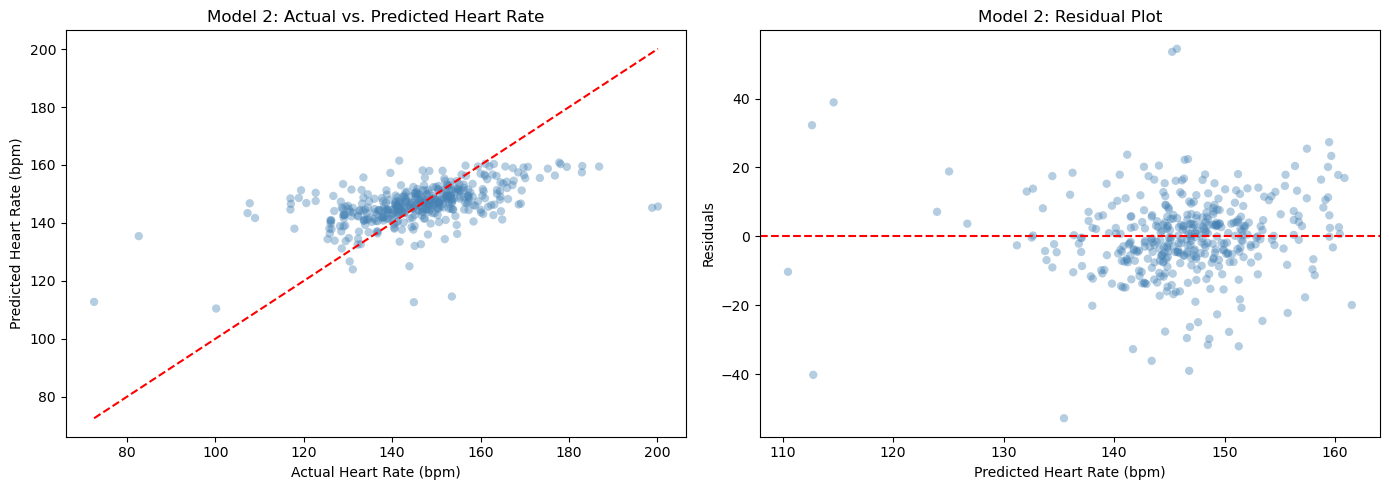

In [57]:
# Model 2: Pre-Run Heart Rate Predictor (Linear Regression)

hr_features = [
    'DISTANCE_MILES', 'MINUTES_PER_MILE', 'ELEVATION_GAIN_FEET',
    'TEMPERATURE', 'HUMIDITY', 'WIND_SPEED'
]

hr_df = running_weather_df[hr_features + ['AVERAGE_HEARTRATE']].dropna()
hr_df = hr_df[
    (hr_df['MINUTES_PER_MILE'] <= 15) &
    (hr_df['ELEVATION_GAIN_FEET'] <= 2000)
]

X = hr_df[hr_features]
y = hr_df['AVERAGE_HEARTRATE']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

hr_model = LinearRegression()
hr_model.fit(X_train_scaled, y_train)
y_pred = hr_model.predict(X_test_scaled)

X_train_sm = sm.add_constant(X_train_scaled)
hr_ols = sm.OLS(y_train, X_train_sm).fit()
print(hr_ols.summary())

metrics_df = pd.DataFrame({
    'Metric': ['R²', 'Adjusted R²', 'MAE', 'RMSE (bpm)'],
    'Value': [
        round(r2_score(y_test, y_pred), 3),
        round(hr_ols.rsquared_adj, 3),
        round(mean_absolute_error(y_test, y_pred), 3),
        round(np.sqrt(mean_squared_error(y_test, y_pred)), 3)
    ]
})
display(metrics_df)

coef_df = pd.DataFrame({
    'Feature': hr_features,
    'Coefficient': hr_model.coef_
}).sort_values('Coefficient', ascending=False).reset_index(drop=True)
display(coef_df)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_test, y_pred, alpha=0.4, color='steelblue', edgecolors='none')
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth=1.5)
axes[0].set_xlabel('Actual Heart Rate (bpm)')
axes[0].set_ylabel('Predicted Heart Rate (bpm)')
axes[0].set_title('Model 2: Actual vs. Predicted Heart Rate')

residuals = y_test - y_pred
axes[1].scatter(y_pred, residuals, alpha=0.4, color='steelblue', edgecolors='none')
axes[1].axhline(0, color='red', linestyle='--', linewidth=1.5)
axes[1].set_xlabel('Predicted Heart Rate (bpm)')
axes[1].set_ylabel('Residuals')
axes[1].set_title('Model 2: Residual Plot')

plt.tight_layout()
plt.savefig('model2_heartrate_residuals.png', dpi=150, bbox_inches='tight')
plt.show()

## Conclusion
This analysis set out to answer a single strategic question: is Strava sitting on a performance intelligence layer that it hasn't yet built? The answer is yes.

**What the data showed**

Seven years of personal training data across three analyses points to the same conclusion. The ACWR dashboard demonstrates that Strava already has every data point required to flag dangerous spikes in training load before they result in injury.
The kudos model shows that engagement is driven by effort and sharing behavior, not timing, meaning Strava can meaningfully move the needle on engagement with minimal friction at the point of upload. 
The heart rate model reveals that pace, distance, and elevation explain only 30% of HR variation with the remaining 70% likely driven by recovery, sleep, and physiological signals that Strava doesn't currently surface.

**Product Recommendations**

Four features emerge directly from this analysis:

1. **ACWR Injury Risk Dashboard** — Surface a weekly training load status and safe long run ceiling natively in the app. Strava's Fitness & Freshness model is a natural home for this feature. Athletes who stay healthy stay engaged.

2. **Engagement Prompts at Upload** — Strava already prompts photo uploads. Extending this to comment prompts and surfacing the activity to followers and encouraging interaction at the moment of upload would directly increase the engagement signals this model identified as most predictive.

3. **Pre-Run Readiness Score** — A composite score combining ACWR training load, sleep quality, HRV, and weather conditions would give athletes a meaningful signal before they start. This analysis demonstrates the framework; the full model requires integration of recovery and physiological data that Strava is uniquely positioned to access through device partnerships.

4. **Strava Year in Sport Improvements** — By integrating weather data more uniformly into Strava data, we can add fun engagement items such as "Top 5 Hottest Runs in 2026" to a user's Year in Sport experience.

**Limitations & Future State**

This analysis is a single-athlete proof of concept. The models presented here would be significantly more powerful at platform scale across millions of athletes. Three data sources were identified but not fully explored due to access limitations: Stryd running power meter data, which would add a more precise effort metric than pace or HR alone; Garmin sleep and HRV data, which represents the likely missing 70% of the HR prediction model; and multi-athlete data, which would allow the kudos model to separate individual social network effects from true engagement drivers.